# COF Total Precipitation Rain-Type Rank Map

## Purpose
This notebook analyzes the contributions of 13 co-occurrence feature (COF) precipitation types to **total precipitation** across multiple observational and global storm-resolving model (GSRM) sources. It identifies the spatially dominant precipitation types at each grid cell and produces both global maps and regional summary plots for comparison across datasets.

## Input Data
Monthly precipitation statistics on a HEALPix zoom 8 grid, one NetCDF file per source. The notebook reads the CFS copy, which is identical file by file to the production copy in
`/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/`:
```
/global/cfs/cdirs/wcm_shr/hk25/cof_masks/stats/monthly/<source>_monthly_rainmap_cof_hp8_v1.nc
```
These files are generated by:
- **Python script:** `waccem/gsrm_cooccurrencefeature/scripts/calc_monthly_rainmap_by_cof.py`. It reads the COF mask store (`<source>_cofmasks_hp8_v1.zarr`) with its total precipitation `tot_pr` (the window mean of the source's own hourly precipitation, written by
  Step 1), so the masks, the cloud types and the total share one precipitation definition, and it assigns every grid cell and time step to at most one category by priority: the twelve exclusive categories add up to `tot_pr`
- **Pipeline runner** (Steps 1-3 and this script for all six sources; it made the files of the 2026-09-20 re-processing): `waccem/gsrm_cooccurrencefeature/scripts/run_cof_pipeline.py` (`docs/procedures/run_cof_pipeline.md`)
- **Slurm task array** (submits jobs for all sources): `waccem/gsrm_cooccurrencefeature/slurm/slurm_calc_monthly_rainmap_by_cof.sh`

**Sources:** OBS (IMERGv7), SCREAM (m1), ICON (m2), NICAM (m3), UM (m4), CASESM2 (m5)

**Land mask:** HEALPix topography/land-fraction file from SCREAM (`scream2D_hrly_topo_hp8_v7.zarr`)

## Precipitation Types (13 categories)
| # | Type | Description |
|---|------|-------------|
| 1 | MCS | Isolated MCS |
| 2 | AR | Isolated AR |
| 3 | ETC | Isolated ETC |
| 4 | TC | Tropical cyclone |
| 5 | MCS-AR | MCS co-occurring with AR |
| 6 | MCS-ETC | MCS co-occurring with ETC |
| 7 | AR-ETC | AR co-occurring with ETC |
| 8 | MCS-AR-ETC | MCS + AR + ETC co-occurrence |
| 9 | DC | Deep convection (untracked) |
| 10 | ND | Non-deep convection (untracked) |
| 11 | ST | Stratiform (untracked) |
| 12 | DZ | Drizzle (untracked) |
| 13 | Residual | Precipitation not attributed to any type |

## Analysis Steps
1. **Load & combine** all source files into a single `xarray.Dataset` with a `source` dimension; filter out polar latitudes (> 60°N/S)
2. **Compute precipitation fractions** for each of the 13 types relative to total precipitation
3. **Separate land / ocean** using a land-fraction threshold (≥ 90% for land, < 90% for ocean)
4. **Subset by region**: Tropics (20°S–20°N), N. Hemisphere extratropics (20–60°N), S. Hemisphere extratropics (20–60°S)
5. **Rank dominant types** per grid cell (top-1, top-2, top-3) using `get_ranked_precip_types()`
6. **Compute area-mean fractions** per region × land/ocean × source

## Plots Generated
| Figure | Description | Output File |
|--------|-------------|-------------|
| Global rank-1 map | Fraction contributed by the single largest type per cell (6-panel, one per source) | `globalmap_precip_rank1_frac_annual.png` |
| Global rank-2 map | Fraction contributed by the second-largest type per cell | `globalmap_precip_rank2_frac_annual.png` |
| Top-2 combined map | Combined fraction of the top 2 types | `globalmap_precip_rank12_frac_annual.png` |
| Top-3 combined map | Combined fraction of the top 3 types | `globalmap_precip_rank123_frac_annual.png` |
| Ranked-type maps | Categorical maps of the rank-1 and rank-2 precipitation types (one figure) and of the rank-3 type, colored by category | `globalmap_precip_rank1_rank2_types_annual.png`, `globalmap_precip_rank3_types_annual.png` |
| 6×6 pie-chart summary | Regional pie charts (Land/Ocean × Tropics/N.H./S.H.) for all 6 sources in a single figure | `PieChart_StormType_Fraction_Total_6x6_combined.png` |

Output figures are saved to: `/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_202609/`


In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, BoundaryNorm
import copy, os
import colormaps as cmaps
import easygems.healpix as egh

In [ ]:
# rootdir = '/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/'
# rootdir = '/pscratch/sd/w/wcmca1/hackathon/tmp/full_reprocess/cof_masks/stats/monthly/'
# rootdir = '/pscratch/sd/w/wcmca1/hackathon/tmp/round2/cof_masks/stats/monthly/'
rootdir = '/global/cfs/cdirs/wcm_shr/hk25/cof_masks/stats/monthly/'

name_map = {
    'obs': 'IMERGv7',
    'm1': 'scream',
    'm2': 'icon_d3hp003',
    'm3': 'nicam_gl11',
    'm4': 'um_glm_n2560_RAL3p3',
    'm5': 'casesm2_10km_nocumulus',
}
name_map_plot = {
    'obs': 'OBS',
    'm1': 'SCREAM',
    'm2': 'ICON',
    'm3': 'NICAM',
    'm4': 'UM',
    'm5': 'CASESM2',
}

# Input filenames
filenames = {key:f'{rootdir}{value}_monthly_rainmap_cof_hp8_v1.nc' for key,value in name_map.items()}

landmaskfile = '/global/cfs/cdirs/m4581/gsharing/hackathon/scream-cess-healpix/scream2D_hrly_topo_hp8_v7.zarr'

# figdir = '/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/'
figdir = '/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_202609/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

### Check if input files exist

In [ ]:
for key, value in filenames.items():
    print(f'{value}: {os.path.isfile(value)}')

In [ ]:
dstop = xr.open_dataset(landmaskfile)
ter = dstop.ELEV
landfrac = dstop.LANDFRAC
dstop

In [ ]:
im = egh.healpix_show(ter, cmap='terrain')
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Elevation (m)')

In [ ]:
im = egh.healpix_show(landfrac, cmap='Greens', vmin=0, vmax=1)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Land Fraction')

## Read and combine all sources to a single DataSet

In [ ]:
drop_vars = []
# Read all files and combine them with a new dimension 'source'
ds = xr.open_mfdataset(list(filenames.values()), combine='nested', concat_dim='source', drop_variables=drop_vars).squeeze()
# Assign new coordinate 'source' using name_map dictionary keys
ds['source'] = list(name_map.keys())
# ds = ds.pipe(egh.attach_coords)
# Load lat/lon coordinates in memory
hp_lat = ds.lat.load()
hp_lon = ds.lon.load()
ds

In [ ]:
ds.ntimes.sum(dim='time').values

In [ ]:
ds.sel(source='obs').time.min().values, ds.sel(source='obs').time.max().values

## Filter DataSet in the Polar Region (No coherent storm types in polar region)

In [ ]:
polar_lat = 60

ds = ds.where((ds.lat <= polar_lat) & (ds.lat >= -polar_lat))
ds

### Compute feature precipitation amount & fraction

In [ ]:
# Get time interval from attributes
time_interval = float(ds.attrs['time_interval'])

# Calculate total hours accounting for time interval
# ntimes is the number of timesteps, multiply by time_interval to get actual hours
ntimes = ds.ntimes.sum(dim='time')
nhours = ntimes * time_interval

# Sum monthly precipitation amount [mm], divided by total hours to get mm/day
tot_pcp_all = (24. * ds.precipitation.sum(dim='time') / nhours).compute()

# Original features
mcs_pcp_all = (24. * ds.mcs_precipitation.sum(dim='time') / nhours).compute()
ar_pcp_all = (24. * ds.ar_precipitation.sum(dim='time') / nhours).compute()
etc_pcp_all = (24. * ds.etc_precipitation.sum(dim='time') / nhours).compute()
tc_pcp_all = (24. * ds.tc_precipitation.sum(dim='time') / nhours).compute()

# Isolated features only
mcs_iso_pcp_all = (24. * ds.mcs_iso_precipitation.sum(dim='time') / nhours).compute()
ar_iso_pcp_all = (24. * ds.ar_iso_precipitation.sum(dim='time') / nhours).compute()
etc_iso_pcp_all = (24. * ds.etc_iso_precipitation.sum(dim='time') / nhours).compute()
# Co-occurrence features
mcs_ar_pcp_all = (24. * ds.mcs_ar_precipitation.sum(dim='time') / nhours).compute()
mcs_etc_pcp_all = (24. * ds.mcs_etc_precipitation.sum(dim='time') / nhours).compute()
ar_etc_pcp_all = (24. * ds.ar_etc_precipitation.sum(dim='time') / nhours).compute()
mcs_ar_etc_pcp_all = (24. * ds.mcs_ar_etc_precipitation.sum(dim='time') / nhours).compute()
# Cloud types (not tracked)
dc_pcp_all = (24. * ds.dc_precipitation.sum(dim='time') / nhours).compute()
nd_pcp_all = (24. * ds.nd_precipitation.sum(dim='time') / nhours).compute()
st_pcp_all = (24. * ds.st_precipitation.sum(dim='time') / nhours).compute()
dz_pcp_all = (24. * ds.dz_precipitation.sum(dim='time') / nhours).compute()
# Residual precipitation (mutually-exclusive decomposition: isolated + co-occurrence +
# cloud types. Using mcs_pcp_all/ar_pcp_all/etc_pcp_all here would double-count
# co-occurring cells, since e.g. mcs_pcp_all and ar_pcp_all both include MCS-AR overlap
# pixels. Inputs are already in mm/day, so no additional 24./nhours rescaling is applied.
res_pcp_all = tot_pcp_all - (
    mcs_iso_pcp_all + ar_iso_pcp_all + etc_iso_pcp_all + tc_pcp_all + 
    mcs_ar_pcp_all + mcs_etc_pcp_all + ar_etc_pcp_all + mcs_ar_etc_pcp_all + 
    dc_pcp_all + nd_pcp_all + st_pcp_all + dz_pcp_all)

# Calculate precipitation fractions
# Original features
mcs_pcpfrac_all = 100. * mcs_pcp_all / tot_pcp_all
tc_pcpfrac_all = 100. * tc_pcp_all / tot_pcp_all

# Isolated features only
mcs_iso_pcpfrac_all = 100. * mcs_iso_pcp_all / tot_pcp_all
ar_iso_pcpfrac_all = 100. * ar_iso_pcp_all / tot_pcp_all
tc_pcpfrac_all = 100. * tc_pcp_all / tot_pcp_all
etc_iso_pcpfrac_all = 100. * etc_iso_pcp_all / tot_pcp_all
# Co-occurrence features
mcs_ar_pcpfrac_all = 100. * mcs_ar_pcp_all / tot_pcp_all
mcs_etc_pcpfrac_all = 100. * mcs_etc_pcp_all / tot_pcp_all
ar_etc_pcpfrac_all = 100. * ar_etc_pcp_all / tot_pcp_all
mcs_ar_etc_pcpfrac_all = 100. * mcs_ar_etc_pcp_all / tot_pcp_all
# Cloud types (not tracked)
dc_pcpfrac_all = 100. * dc_pcp_all / tot_pcp_all
nd_pcpfrac_all = 100. * nd_pcp_all / tot_pcp_all
st_pcpfrac_all = 100. * st_pcp_all / tot_pcp_all
dz_pcpfrac_all = 100. * dz_pcp_all / tot_pcp_all
# Residual precipitation
res_pcpfrac_all = 100. * res_pcp_all / tot_pcp_all

In [ ]:
im = egh.healpix_show(res_pcpfrac_all.sel(source='obs'), vmin=0, vmax=100, cmap='jet')
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Residual Precipitation Fraction (%)')

### Compute feature frequency

In [ ]:
# # Calculate number of feature mask hours
# # Original features
# mcs_count_all = ds.mcs_count.sum(dim='time').compute()
# ar_count_all = ds.ar_count.sum(dim='time').compute()
# etc_count_all = ds.etc_count.sum(dim='time').compute()
# tc_count_all = ds.tc_count.sum(dim='time').compute()

# # Isolated features only
# mcs_iso_count_all = ds.mcs_iso_count.sum(dim='time').compute()
# ar_iso_count_all = ds.ar_iso_count.sum(dim='time').compute()
# etc_iso_count_all = ds.etc_iso_count.sum(dim='time').compute()
# # Co-occurrence features
# mcs_ar_count_all = ds.mcs_ar_count.sum(dim='time').compute()
# mcs_etc_count_all = ds.mcs_etc_count.sum(dim='time').compute()
# ar_etc_count_all = ds.ar_etc_count.sum(dim='time').compute()
# mcs_ar_etc_count_all = ds.mcs_ar_etc_count.sum(dim='time').compute()
# # Cloud types (not tracked)
# dc_count_all = ds.dc_count.sum(dim='time').compute()
# nd_count_all = ds.nd_count.sum(dim='time').compute()
# st_count_all = ds.st_count.sum(dim='time').compute()
# dz_count_all = ds.dz_count.sum(dim='time').compute()

# # Calculate feature mask frequencies (as percentages)
# # Original features
# mcs_freq_all = 100. * mcs_count_all / nhours
# ar_freq_all = 100. * ar_count_all / nhours
# etc_freq_all = 100. * etc_count_all / nhours
# tc_freq_all = 100. * tc_count_all / nhours

# # Isolated features only
# mcs_iso_freq_all = 100. * mcs_iso_count_all / nhours
# ar_iso_freq_all = 100. * ar_iso_count_all / nhours
# etc_iso_freq_all = 100. * etc_iso_count_all / nhours
# # Co-occurrence features
# mcs_ar_freq_all = 100. * mcs_ar_count_all / nhours
# mcs_etc_freq_all = 100. * mcs_etc_count_all / nhours
# ar_etc_freq_all = 100. * ar_etc_count_all / nhours
# mcs_ar_etc_freq_all = 100. * mcs_ar_etc_count_all / nhours
# # Cloud types (not tracked)
# dc_freq_all = 100. * dc_count_all / nhours
# nd_freq_all = 100. * nd_count_all / nhours
# st_freq_all = 100. * st_count_all / nhours
# dz_freq_all = 100. * dz_count_all / nhours

### Compute precipitation frequency

In [ ]:
# # Number of feature precipitation hours
# # Original features
# mcs_pcpcount_all = ds.mcs_precipitation_count.sum(dim='time').compute()
# ar_pcpcount_all = ds.ar_precipitation_count.sum(dim='time').compute()
# etc_pcpcount_all = ds.etc_precipitation_count.sum(dim='time').compute()
# tc_pcpcount_all = ds.tc_precipitation_count.sum(dim='time').compute()

# # Isolated features only
# mcs_iso_pcpcount_all = ds.mcs_precipitation_count.sum(dim='time').compute()
# ar_iso_pcpcount_all = ds.ar_precipitation_count.sum(dim='time').compute()
# etc_iso_pcpcount_all = ds.etc_precipitation_count.sum(dim='time').compute()
# # Co-occurrence features
# mcs_ar_pcpcount_all = ds.mcs_ar_precipitation_count.sum(dim='time').compute()
# mcs_etc_pcpcount_all = ds.mcs_etc_precipitation_count.sum(dim='time').compute()
# ar_etc_pcpcount_all = ds.ar_etc_precipitation_count.sum(dim='time').compute()
# mcs_ar_etc_pcpcount_all = ds.mcs_ar_etc_precipitation_count.sum(dim='time').compute()

# # Calculate feature frequencies (as percentages)
# # Original features
# mcs_pcpfreq_all = 100 * mcs_pcpcount_all / ntimes
# ar_pcpfreq_all = 100 * ar_pcpcount_all / ntimes
# etc_pcpfreq_all = 100 * etc_pcpcount_all / ntimes
# tc_pcpfreq_all = 100 * tc_pcpcount_all / ntimes

# # Isolated features only
# mcs_iso_pcpfreq_all = 100 * mcs_iso_pcpcount_all / ntimes
# ar_iso_pcpfreq_all = 100 * ar_iso_pcpcount_all / ntimes
# etc_iso_pcpfreq_all = 100 * etc_iso_pcpcount_all / ntimes
# # Co-occurrence features
# mcs_ar_pcpfreq_all = 100 * mcs_ar_pcpcount_all / ntimes
# mcs_etc_pcpfreq_all = 100 * mcs_etc_pcpcount_all / ntimes
# ar_etc_pcpfreq_all = 100 * ar_etc_pcpcount_all / ntimes
# mcs_ar_etc_pcpfreq_all = 100 * mcs_ar_etc_pcpcount_all / ntimes

In [ ]:
# im = egh.healpix_show(mcs_freq_all.sel(source='obs'))
# plt.colorbar(im, orientation='horizontal', pad=0.05, label='All MCS Frequency (%)')

## Filter data by latitude bands

### Tropics

In [ ]:
tropics_lat = [-20, 20]
# Land threshold
land_thresh = 0.9

# Isolated features
mcs_iso_frac_trop = mcs_iso_pcpfrac_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
ar_iso_frac_trop = ar_iso_pcpfrac_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
etc_iso_frac_trop = etc_iso_pcpfrac_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
tc_frac_trop = tc_pcpfrac_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
# Co-occurrence features
mcs_ar_frac_trop = mcs_ar_pcpfrac_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
mcs_etc_frac_trop = mcs_etc_pcpfrac_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
ar_etc_frac_trop = ar_etc_pcpfrac_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
mcs_ar_etc_frac_trop = mcs_ar_etc_pcpfrac_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
# Cloud types (not tracked)
dc_frac_trop = dc_pcpfrac_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
nd_frac_trop = nd_pcpfrac_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
st_frac_trop = st_pcpfrac_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
dz_frac_trop = dz_pcpfrac_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
# Residual fraction
res_frac_trop = res_pcpfrac_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))

# LAND-ONLY TROPICAL REGIONS
# Isolated features
mcs_iso_frac_trop_l = mcs_iso_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac >= land_thresh))
ar_iso_frac_trop_l = ar_iso_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac >= land_thresh))
etc_iso_frac_trop_l = etc_iso_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac >= land_thresh))
tc_frac_trop_l = tc_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac >= land_thresh))
# Co-occurrence features
mcs_ar_frac_trop_l = mcs_ar_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac >= land_thresh))
mcs_etc_frac_trop_l = mcs_etc_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac >= land_thresh))
ar_etc_frac_trop_l = ar_etc_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac >= land_thresh))
mcs_ar_etc_frac_trop_l = mcs_ar_etc_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac >= land_thresh))
# Cloud types (not tracked)
dc_frac_trop_l = dc_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac >= land_thresh))
nd_frac_trop_l = nd_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac >= land_thresh))
st_frac_trop_l = st_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac >= land_thresh))
dz_frac_trop_l = dz_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac >= land_thresh))
# Residual fraction
res_frac_trop_l = res_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac >= land_thresh))

# OCEAN-ONLY TROPICAL REGIONS
# Isolated features
mcs_iso_frac_trop_o = mcs_iso_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac < land_thresh))
ar_iso_frac_trop_o = ar_iso_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac < land_thresh))
etc_iso_frac_trop_o = etc_iso_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac < land_thresh))
tc_frac_trop_o = tc_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac < land_thresh))
# Co-occurrence features
mcs_ar_frac_trop_o = mcs_ar_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac < land_thresh))
mcs_etc_frac_trop_o = mcs_etc_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac < land_thresh))
ar_etc_frac_trop_o = ar_etc_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac < land_thresh))
mcs_ar_etc_frac_trop_o = mcs_ar_etc_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac < land_thresh))
# Cloud types (not tracked)
dc_frac_trop_o = dc_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac < land_thresh))
nd_frac_trop_o = nd_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac < land_thresh))
st_frac_trop_o = st_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac < land_thresh))
dz_frac_trop_o = dz_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac < land_thresh))
# Residual fraction
res_frac_trop_o = res_pcpfrac_all.where(((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat))) & (landfrac < land_thresh))

### Mid-latitude

In [ ]:
# LAND-ONLY Extratropical Northern Hemisphere
# Isolated features
mcs_iso_frac_nh_l = mcs_iso_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac >= land_thresh))
ar_iso_frac_nh_l = ar_iso_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac >= land_thresh))
etc_iso_frac_nh_l = etc_iso_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac >= land_thresh))
tc_frac_nh_l = tc_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac >= land_thresh))
# Co-occurrence features
mcs_ar_frac_nh_l = mcs_ar_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac >= land_thresh))
mcs_etc_frac_nh_l = mcs_etc_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac >= land_thresh))
ar_etc_frac_nh_l = ar_etc_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac >= land_thresh))
mcs_ar_etc_frac_nh_l = mcs_ar_etc_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac >= land_thresh))
# Cloud types (not tracked)
dc_frac_nh_l = dc_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac >= land_thresh))
nd_frac_nh_l = nd_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac >= land_thresh))
st_frac_nh_l = st_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac >= land_thresh))
dz_frac_nh_l = dz_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac >= land_thresh))
# Residual fraction
res_frac_nh_l = res_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac >= land_thresh))

# LAND-ONLY Extratropical Southern Hemisphere
# Isolated features
mcs_iso_frac_sh_l = mcs_iso_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac >= land_thresh))
ar_iso_frac_sh_l = ar_iso_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac >= land_thresh))
etc_iso_frac_sh_l = etc_iso_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac >= land_thresh))
tc_frac_sh_l = tc_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac >= land_thresh))
# Co-occurrence features
mcs_ar_frac_sh_l = mcs_ar_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac >= land_thresh))
mcs_etc_frac_sh_l = mcs_etc_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac >= land_thresh))
ar_etc_frac_sh_l = ar_etc_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac >= land_thresh))
mcs_ar_etc_frac_sh_l = mcs_ar_etc_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac >= land_thresh))
# Cloud types (not tracked)
dc_frac_sh_l = dc_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac >= land_thresh))
nd_frac_sh_l = nd_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac >= land_thresh))
st_frac_sh_l = st_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac >= land_thresh))
dz_frac_sh_l = dz_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac >= land_thresh))
# Residual fraction
res_frac_sh_l = res_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac >= land_thresh))

# OCEAN-ONLY Extratropical Northern Hemisphere
# Isolated features
mcs_iso_frac_nh_o = mcs_iso_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac < land_thresh))
ar_iso_frac_nh_o = ar_iso_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac < land_thresh))
etc_iso_frac_nh_o = etc_iso_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac < land_thresh))
tc_frac_nh_o = tc_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac < land_thresh))
# Co-occurrence features
mcs_ar_frac_nh_o = mcs_ar_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac < land_thresh))
mcs_etc_frac_nh_o = mcs_etc_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac < land_thresh))
ar_etc_frac_nh_o = ar_etc_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac < land_thresh))
mcs_ar_etc_frac_nh_o = mcs_ar_etc_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac < land_thresh))
# Cloud types (not tracked)
dc_frac_nh_o = dc_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac < land_thresh))
nd_frac_nh_o = nd_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac < land_thresh))
st_frac_nh_o = st_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac < land_thresh))
dz_frac_nh_o = dz_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac < land_thresh))
# Residual fraction
res_frac_nh_o = res_pcpfrac_all.where((hp_lat > max(tropics_lat)) & (landfrac < land_thresh))

# OCEAN-ONLY Extratropical Southern Hemisphere
# Isolated features
mcs_iso_frac_sh_o = mcs_iso_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac < land_thresh))
ar_iso_frac_sh_o = ar_iso_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac < land_thresh))
etc_iso_frac_sh_o = etc_iso_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac < land_thresh))
tc_frac_sh_o = tc_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac < land_thresh))
# Co-occurrence features
mcs_ar_frac_sh_o = mcs_ar_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac < land_thresh))
mcs_etc_frac_sh_o = mcs_etc_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac < land_thresh))
ar_etc_frac_sh_o = ar_etc_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac < land_thresh))
mcs_ar_etc_frac_sh_o = mcs_ar_etc_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac < land_thresh))
# Cloud types (not tracked)
dc_frac_sh_o = dc_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac < land_thresh))
nd_frac_sh_o = nd_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac < land_thresh))
st_frac_sh_o = st_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac < land_thresh))
dz_frac_sh_o = dz_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac < land_thresh))
# Residual fraction
res_frac_sh_o = res_pcpfrac_all.where((hp_lat < min(tropics_lat)) & (landfrac < land_thresh))

In [ ]:
egh.healpix_show(ar_etc_frac_sh_o.sel(source='obs'))

## Calculate regional mean fractions

### Tropics

In [ ]:
# Isolated features
mcs_iso_frac_trop_avg = mcs_iso_frac_trop.mean(dim='cell')
ar_iso_frac_trop_avg = ar_iso_frac_trop.mean(dim='cell')
etc_iso_frac_trop_avg = etc_iso_frac_trop.mean(dim='cell')
tc_frac_trop_avg = tc_frac_trop.mean(dim='cell')
# Co-occurring features
mcs_ar_frac_trop_avg = mcs_ar_frac_trop.mean(dim='cell')
mcs_etc_frac_trop_avg = mcs_etc_frac_trop.mean(dim='cell')
ar_etc_frac_trop_avg = ar_etc_frac_trop.mean(dim='cell')
mcs_ar_etc_frac_trop_avg = mcs_ar_etc_frac_trop.mean(dim='cell')
# Cloud types (not tracked)
dc_frac_trop_avg = dc_frac_trop.mean(dim='cell')
nd_frac_trop_avg = nd_frac_trop.mean(dim='cell')
st_frac_trop_avg = st_frac_trop.mean(dim='cell')
dz_frac_trop_avg = dz_frac_trop.mean(dim='cell')
# Residual fraction
res_frac_trop_avg = res_frac_trop.mean(dim='cell')

# LAND-ONLY TROPICAL REGIONS

# Isolated features
mcs_iso_frac_trop_l_avg = mcs_iso_frac_trop_l.mean(dim='cell')
ar_iso_frac_trop_l_avg = ar_iso_frac_trop_l.mean(dim='cell')
etc_iso_frac_trop_l_avg = etc_iso_frac_trop_l.mean(dim='cell')
tc_frac_trop_l_avg = tc_frac_trop_l.mean(dim='cell')
# Co-occurring features
mcs_ar_frac_trop_l_avg = mcs_ar_frac_trop_l.mean(dim='cell')
mcs_etc_frac_trop_l_avg = mcs_etc_frac_trop_l.mean(dim='cell')
ar_etc_frac_trop_l_avg = ar_etc_frac_trop_l.mean(dim='cell')
mcs_ar_etc_frac_trop_l_avg = mcs_ar_etc_frac_trop_l.mean(dim='cell')
# Cloud types (not tracked)
dc_frac_trop_l_avg = dc_frac_trop_l.mean(dim='cell')
nd_frac_trop_l_avg = nd_frac_trop_l.mean(dim='cell')
st_frac_trop_l_avg = st_frac_trop_l.mean(dim='cell')
dz_frac_trop_l_avg = dz_frac_trop_l.mean(dim='cell')
# Residual fraction
res_frac_trop_l_avg = res_frac_trop_l.mean(dim='cell')

# OCEAN-ONLY TROPICAL REGIONS

# Isolated features
mcs_iso_frac_trop_o_avg = mcs_iso_frac_trop_o.mean(dim='cell')
ar_iso_frac_trop_o_avg = ar_iso_frac_trop_o.mean(dim='cell')
etc_iso_frac_trop_o_avg = etc_iso_frac_trop_o.mean(dim='cell')
tc_frac_trop_o_avg = tc_frac_trop_o.mean(dim='cell')
# Co-occurring features
mcs_ar_frac_trop_o_avg = mcs_ar_frac_trop_o.mean(dim='cell')
mcs_etc_frac_trop_o_avg = mcs_etc_frac_trop_o.mean(dim='cell')
ar_etc_frac_trop_o_avg = ar_etc_frac_trop_o.mean(dim='cell')
mcs_ar_etc_frac_trop_o_avg = mcs_ar_etc_frac_trop_o.mean(dim='cell')
# Cloud types (not tracked)
dc_frac_trop_o_avg = dc_frac_trop_o.mean(dim='cell')
nd_frac_trop_o_avg = nd_frac_trop_o.mean(dim='cell')
st_frac_trop_o_avg = st_frac_trop_o.mean(dim='cell')
dz_frac_trop_o_avg = dz_frac_trop_o.mean(dim='cell')
# Residual fraction
res_frac_trop_o_avg = res_frac_trop_o.mean(dim='cell')

### Mid-latitude

In [ ]:
# LAND-ONLY Extratropical Northern Hemisphere

# Isolated features
mcs_iso_frac_nh_l = mcs_iso_frac_nh_l.mean(dim='cell')
ar_iso_frac_nh_l = ar_iso_frac_nh_l.mean(dim='cell')
etc_iso_frac_nh_l = etc_iso_frac_nh_l.mean(dim='cell')
tc_frac_nh_l = tc_frac_nh_l.mean(dim='cell')
# Co-occurring features
mcs_ar_frac_nh_l = mcs_ar_frac_nh_l.mean(dim='cell')
mcs_etc_frac_nh_l = mcs_etc_frac_nh_l.mean(dim='cell')
ar_etc_frac_nh_l = ar_etc_frac_nh_l.mean(dim='cell')
mcs_ar_etc_frac_nh_l = mcs_ar_etc_frac_nh_l.mean(dim='cell')
# Cloud types (not tracked)
dc_frac_nh_l = dc_frac_nh_l.mean(dim='cell')
nd_frac_nh_l = nd_frac_nh_l.mean(dim='cell')
st_frac_nh_l = st_frac_nh_l.mean(dim='cell')
dz_frac_nh_l = dz_frac_nh_l.mean(dim='cell')
# Residual fraction
res_frac_nh_l = res_frac_nh_l.mean(dim='cell')

# LAND-ONLY Extratropical Southern Hemisphere

# Isolated features
mcs_iso_frac_sh_l = mcs_iso_frac_sh_l.mean(dim='cell')
ar_iso_frac_sh_l = ar_iso_frac_sh_l.mean(dim='cell')
etc_iso_frac_sh_l = etc_iso_frac_sh_l.mean(dim='cell')
tc_frac_sh_l = tc_frac_sh_l.mean(dim='cell')
# Co-occurring features
mcs_ar_frac_sh_l = mcs_ar_frac_sh_l.mean(dim='cell')
mcs_etc_frac_sh_l = mcs_etc_frac_sh_l.mean(dim='cell')
ar_etc_frac_sh_l = ar_etc_frac_sh_l.mean(dim='cell')
mcs_ar_etc_frac_sh_l = mcs_ar_etc_frac_sh_l.mean(dim='cell')
# Cloud types (not tracked)
dc_frac_sh_l = dc_frac_sh_l.mean(dim='cell')
nd_frac_sh_l = nd_frac_sh_l.mean(dim='cell')
st_frac_sh_l = st_frac_sh_l.mean(dim='cell')
dz_frac_sh_l = dz_frac_sh_l.mean(dim='cell')
# Residual fraction
res_frac_sh_l = res_frac_sh_l.mean(dim='cell')

# OCEAN-ONLY Extratropical Northern Hemisphere

# Isolated features
mcs_iso_frac_nh_o = mcs_iso_frac_nh_o.mean(dim='cell')
ar_iso_frac_nh_o = ar_iso_frac_nh_o.mean(dim='cell')
etc_iso_frac_nh_o = etc_iso_frac_nh_o.mean(dim='cell')
tc_frac_nh_o = tc_frac_nh_o.mean(dim='cell')
# Co-occurring features
mcs_ar_frac_nh_o = mcs_ar_frac_nh_o.mean(dim='cell')
mcs_etc_frac_nh_o = mcs_etc_frac_nh_o.mean(dim='cell')
ar_etc_frac_nh_o = ar_etc_frac_nh_o.mean(dim='cell')
mcs_ar_etc_frac_nh_o = mcs_ar_etc_frac_nh_o.mean(dim='cell')
# Cloud types (not tracked)
dc_frac_nh_o = dc_frac_nh_o.mean(dim='cell')
nd_frac_nh_o = nd_frac_nh_o.mean(dim='cell')
st_frac_nh_o = st_frac_nh_o.mean(dim='cell')
dz_frac_nh_o = dz_frac_nh_o.mean(dim='cell')
# Residual fraction
res_frac_nh_o = res_frac_nh_o.mean(dim='cell')

# OCEAN-ONLY Extratropical Southern Hemisphere

# Isolated features
mcs_iso_frac_sh_o = mcs_iso_frac_sh_o.mean(dim='cell')
ar_iso_frac_sh_o = ar_iso_frac_sh_o.mean(dim='cell')
etc_iso_frac_sh_o = etc_iso_frac_sh_o.mean(dim='cell')
tc_frac_sh_o = tc_frac_sh_o.mean(dim='cell')
# Co-occurring features
mcs_ar_frac_sh_o = mcs_ar_frac_sh_o.mean(dim='cell')
mcs_etc_frac_sh_o = mcs_etc_frac_sh_o.mean(dim='cell')
ar_etc_frac_sh_o = ar_etc_frac_sh_o.mean(dim='cell')
mcs_ar_etc_frac_sh_o = mcs_ar_etc_frac_sh_o.mean(dim='cell')
# Cloud types (not tracked)
dc_frac_sh_o = dc_frac_sh_o.mean(dim='cell')
nd_frac_sh_o = nd_frac_sh_o.mean(dim='cell')
st_frac_sh_o = st_frac_sh_o.mean(dim='cell')
dz_frac_sh_o = dz_frac_sh_o.mean(dim='cell')
# Residual fraction
res_frac_sh_o = res_frac_sh_o.mean(dim='cell')

In [ ]:
colormaps = cmaps.WhiteBlueGreenYellowRed
levels = np.arange(0, 40.1, 5)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(dc_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='DC Precipitation Fraction (%)')

In [ ]:
colormaps = cmaps.WhiteBlueGreenYellowRed
levels = np.arange(0, 40.1, 5)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(nd_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='ND Precipitation Fraction (%)')

In [ ]:
colormaps = cmaps.WhiteBlueGreenYellowRed
levels = np.arange(0, 40.1, 5)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(st_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='DC Precipitation Fraction (%)')

In [ ]:
colormaps = cmaps.WhiteBlueGreenYellowRed
levels = np.arange(0, 40.1, 5)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(dz_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='DC Precipitation Fraction (%)')

In [ ]:
# # Compute global mean values
# # Original features
# mcs_freq_all_avg = mcs_freq_all.mean(dim='cell').compute()
# mcs_freq_all_trop_avg = mcs_freq_all_trop.mean(dim='cell').compute()
# mcs_freq_all_extrop_avg = mcs_freq_all_extrop.mean(dim='cell').compute()

# mcs_pcp_all_avg = mcs_pcp_all.mean(dim='cell').compute()
# mcs_pcp_all_trop_avg = mcs_pcp_all_trop.mean(dim='cell').compute()
# mcs_pcp_all_extrop_avg = mcs_pcp_all_extrop.mean(dim='cell').compute()

# tc_freq_all_trop_avg = tc_freq_all_trop.mean(dim='cell').compute()
# tc_pcp_all_trop_avg = tc_pcp_all_trop.mean(dim='cell').compute()

# # Isolated features only
# mcs_iso_freq_all_trop_avg = mcs_iso_freq_all_trop.mean(dim='cell').compute()
# mcs_iso_pcp_all_trop_avg = mcs_iso_pcp_all_trop.mean(dim='cell').compute()
# mcs_iso_pcp_all_extrop_avg = mcs_iso_pcp_all_extrop.mean(dim='cell').compute()

# ar_iso_freq_all_extrop_avg = ar_iso_freq_all_extrop.mean(dim='cell').compute()
# ar_iso_pcp_all_extrop_avg = ar_iso_pcp_all_extrop.mean(dim='cell').compute()

# etc_iso_freq_all_extrop_avg = etc_iso_freq_all_extrop.mean(dim='cell').compute()
# etc_iso_pcp_all_extrop_avg = etc_iso_pcp_all_extrop.mean(dim='cell').compute()

# # Co-occurrence features
# mcs_ar_freq_all_extrop_avg = mcs_ar_freq_all_extrop.mean(dim='cell').compute()
# mcs_ar_pcp_all_extrop_avg = mcs_ar_pcp_all_extrop.mean(dim='cell').compute()

# mcs_etc_freq_all_extrop_avg = mcs_etc_freq_all_extrop.mean(dim='cell').compute()
# mcs_etc_pcp_all_extrop_avg = mcs_etc_pcp_all_extrop.mean(dim='cell').compute()

# ar_etc_freq_all_extrop_avg = ar_etc_freq_all_extrop.mean(dim='cell').compute()
# ar_etc_pcp_all_extrop_avg = ar_etc_pcp_all_extrop.mean(dim='cell').compute()

# mcs_ar_etc_freq_all_extrop_avg = mcs_ar_etc_freq_all_extrop.mean(dim='cell').compute()
# mcs_ar_etc_pcp_all_extrop_avg = mcs_ar_etc_pcp_all_extrop.mean(dim='cell').compute()

# # Cloud types (not tracked)
# dc_freq_all_trop_avg = dc_freq_all_trop.mean(dim='cell').compute()
# dc_pcp_all_trop_avg = dc_pcp_all_trop.mean(dim='cell').compute()
# dc_freq_all_extrop_avg = dc_freq_all_extrop.mean(dim='cell').compute()
# dc_pcp_all_extrop_avg = dc_pcp_all_extrop.mean(dim='cell').compute()

# nd_freq_all_trop_avg = nd_freq_all_trop.mean(dim='cell').compute()
# nd_pcp_all_trop_avg = nd_pcp_all_trop.mean(dim='cell').compute()
# nd_freq_all_extrop_avg = nd_freq_all_extrop.mean(dim='cell').compute()
# nd_pcp_all_extrop_avg = nd_pcp_all_extrop.mean(dim='cell').compute()

# st_freq_all_trop_avg = st_freq_all_trop.mean(dim='cell').compute()
# st_pcp_all_trop_avg = st_pcp_all_trop.mean(dim='cell').compute()
# st_freq_all_extrop_avg = st_freq_all_extrop.mean(dim='cell').compute()
# st_pcp_all_extrop_avg = st_pcp_all_extrop.mean(dim='cell').compute()

# dz_freq_all_trop_avg = dz_freq_all_trop.mean(dim='cell').compute()
# dz_pcp_all_trop_avg = dz_pcp_all_trop.mean(dim='cell').compute()
# dz_freq_all_extrop_avg = dz_freq_all_extrop.mean(dim='cell').compute()
# dz_pcp_all_extrop_avg = dz_pcp_all_extrop.mean(dim='cell').compute()

## Different way to compute REGIONAL MEAN fraction

In [ ]:
# # All MCS precipitation fractions
# mcs_pcpfrac_all_avg = 100 * (mcs_pcp_all.sum(dim='cell') / tot_pcp_all.sum(dim='cell')).compute()
# mcs_pcpfrac_all_trop_avg = 100 * (mcs_pcp_all_trop.sum(dim='cell') / tot_pcp_all_trop.sum(dim='cell')).compute()
# mcs_pcpfrac_all_extrop_avg = 100 * (mcs_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()

# # Extratropics isolated & co-occurring MCS precipitation fractions
# mcs_iso_pcpfrac_all_extrop_avg = 100 * (mcs_iso_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
# mcs_ar_pcpfrac_all_extrop_avg = 100 * (mcs_ar_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
# mcs_etc_pcpfrac_all_extrop_avg = 100 * (mcs_etc_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
# mcs_ar_etc_pcpfrac_all_extrop_avg = 100 * (mcs_ar_etc_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()

# ar_etc_pcpfrac_all_extrop_avg = 100 * (ar_etc_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()

# # Cloud types
# dc_pcpfrac_all_trop_avg = 100 * (dc_pcp_all_trop.sum(dim='cell') / tot_pcp_all_trop.sum(dim='cell')).compute()
# dc_pcpfrac_all_extrop_avg = 100 * (dc_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
# nd_pcpfrac_all_trop_avg = 100 * (nd_pcp_all_trop.sum(dim='cell') / tot_pcp_all_trop.sum(dim='cell')).compute()
# nd_pcpfrac_all_extrop_avg = 100 * (nd_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
# st_pcpfrac_all_trop_avg = 100 * (st_pcp_all_trop.sum(dim='cell') / tot_pcp_all_trop.sum(dim='cell')).compute()
# st_pcpfrac_all_extrop_avg = 100 * (st_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
# dz_pcpfrac_all_trop_avg = 100 * (dz_pcp_all_trop.sum(dim='cell') / tot_pcp_all_trop.sum(dim='cell')).compute()
# dz_pcpfrac_all_extrop_avg = 100 * (dz_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()

## Sanity check: sum of all type fractions, residual fraction

In [ ]:
# Total number of precipitation types
# Isolated features only
total_iso_pcp_all = mcs_iso_pcp_all + ar_iso_pcp_all + etc_iso_pcp_all + tc_pcp_all
# Co-occurrence features
total_cof_pcp_all = mcs_ar_pcp_all + ar_etc_pcp_all + mcs_etc_pcp_all + mcs_ar_etc_pcp_all
# Cloud types (not tracked)
total_cloudtypes_pcp_all = dc_pcp_all + nd_pcp_all + st_pcp_all + dz_pcp_all
# All features
total_feature_pcp_all = total_iso_pcp_all + total_cof_pcp_all + total_cloudtypes_pcp_all
# Residual precipitation not accounted for by identified features
res_pcp_all = tot_pcp_all - total_iso_pcp_all - total_cof_pcp_all - total_cloudtypes_pcp_all

# Precipitation fractions
res_pcpfrac_all = 100. * res_pcp_all / tot_pcp_all
total_feature_pcpfrac_all = 100. * total_feature_pcp_all / tot_pcp_all

In [ ]:
# Sum of isolated feature precipitation fractions
total_iso_pcpfrac_all = mcs_iso_pcpfrac_all + ar_iso_pcpfrac_all + etc_iso_pcpfrac_all + tc_pcpfrac_all
# Sum of co-occurring feature precipitation fractions
total_cof_pcpfrac_all = mcs_ar_pcpfrac_all + ar_etc_pcpfrac_all + mcs_etc_pcpfrac_all + mcs_ar_etc_pcpfrac_all
# Sum of cloud type precipitation fractions
total_cloudtypes_pcpfrac_all = dc_pcpfrac_all + nd_pcpfrac_all + st_pcpfrac_all + dz_pcpfrac_all
# Total precipitation fraction accounted for by identified features
total_sum_pcpfrac_all = total_iso_pcpfrac_all + total_cof_pcpfrac_all + total_cloudtypes_pcpfrac_all

In [ ]:
colormaps = cmaps.WhiteBlueGreenYellowRed
# colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
levels = np.arange(0, 110.1, 10)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(total_sum_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='Sum of All Features Rain Fraction (%)')

In [ ]:
colormaps = cmaps.WhiteBlueGreenYellowRed
# colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
levels = np.arange(0, 100.1, 10)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(total_feature_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='All Features Precipitation Fraction (%)')

In [ ]:
img = egh.healpix_show(res_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='Residual Precipitation Fraction (%)')

## Identify map of top N dominant precipitation types

In [ ]:
def get_ranked_precip_types(pcpfrac_dict, source_name, top_n=3):
    """
    Identify the top N dominant precipitation types for each grid cell.
    
    Parameters:
    -----------
    pcpfrac_dict : dict
        Dictionary where keys are precipitation type names and values are 
        xarray.DataArrays with dimensions (source, cell)
    source_name : str
        Name of the source to process (e.g., 'obs', 'm1', 'm2', etc.)
    top_n : int
        Number of top precipitation types to return (default: 3)
    
    Returns:
    --------
    ranked_types : dict
        Dictionary with keys 'rank_1', 'rank_2', 'rank_3', etc., each containing
        an xarray.DataArray with dimensions (cell,) with values 1-9 indicating 
        the precipitation type at that rank
    ranked_values : dict
        Dictionary with keys 'rank_1', 'rank_2', 'rank_3', etc., each containing
        an xarray.DataArray with the actual precipitation fraction values
    """
    
    # Define the precipitation types and their assigned values
    precip_types = {
        'mcs_iso_pcpfrac_all': 1,
        'ar_iso_pcpfrac_all': 2,
        'etc_iso_pcpfrac_all': 3,
        'tc_pcpfrac_all': 4,
        'mcs_ar_pcpfrac_all': 5,
        'mcs_etc_pcpfrac_all': 6,
        'ar_etc_pcpfrac_all': 7,
        'mcs_ar_etc_pcpfrac_all': 8,
        'dc_pcpfrac_all': 9,
        'nd_pcpfrac_all': 10,
        'st_pcpfrac_all': 11,
        'dz_pcpfrac_all': 12,
        'res_pcpfrac_all': 13,
    }
    
    # Stack all precipitation fractions into a single array
    # Shape will be (n_types, n_cells)
    pcpfrac_stack = []
    type_values = []
    
    for ptype, value in precip_types.items():
        if ptype in pcpfrac_dict:
            # Select data for the specified source
            data = pcpfrac_dict[ptype].sel(source=source_name)
            pcpfrac_stack.append(data.values)
            type_values.append(value)
        else:
            print(f"Warning: {ptype} not found in input dictionary")
    
    # Convert to numpy array: shape (n_types, n_cells)
    pcpfrac_array = np.array(pcpfrac_stack)
    type_values_array = np.array(type_values)
    
    # Get indices that would sort the array in descending order
    # argsort returns ascending, so we negate to get descending
    sorted_indices = np.argsort(-pcpfrac_array, axis=0)
    
    # Create output dictionaries
    ranked_types = {}
    ranked_values = {}
    
    # Get coordinates from first precipitation type for creating DataArrays
    first_key = list(precip_types.keys())[0]
    cell_coord = pcpfrac_dict[first_key].cell
    
    # Extract top N ranks
    for rank in range(top_n):
        rank_key = f'rank_{rank+1}'
        
        # Get indices for this rank
        rank_indices = sorted_indices[rank, :]
        
        # Map indices to precipitation type values
        ranked_type_values = type_values_array[rank_indices]
        
        # Get the actual precipitation fraction values for this rank
        # Use advanced indexing to get values
        ranked_pcp_values = pcpfrac_array[rank_indices, np.arange(pcpfrac_array.shape[1])]
        
        # Create DataArrays
        ranked_types[rank_key] = xr.DataArray(
            ranked_type_values,
            dims=['cell'],
            coords={'cell': cell_coord},
            attrs={
                'long_name': f'Rank {rank+1} precipitation type',
                'description': '1=MCS_iso, 2=AR_iso, 3=ETC_iso, 4=TC, 5=MCS-AR, 6=MCS-ETC, 7=AR-ETC, 8=MCS-AR-ETC, 9=DC, 10=ND, 11=ST, 12=DZ, 13=Residual',
                'source': source_name,
                'rank': rank+1
            }
        )
        
        ranked_values[rank_key] = xr.DataArray(
            ranked_pcp_values,
            dims=['cell'],
            coords={'cell': cell_coord},
            attrs={
                'long_name': f'Rank {rank+1} precipitation fraction',
                'units': 'fraction',
                'source': source_name,
                'rank': rank+1
            }
        )
    
    return ranked_types, ranked_values

In [ ]:
def get_all_sources_ranked_types(pcpfrac_dict, top_n=3):
    """
    Get ranked precipitation types for all sources.
    
    Parameters:
    -----------
    pcpfrac_dict : dict
        Dictionary where keys are precipitation type names and values are 
        xarray.DataArrays with dimensions (source, cell)
    top_n : int
        Number of top precipitation types to return (default: 3)
    
    Returns:
    --------
    ranked_types_all : dict
        Dictionary with keys 'rank_1', 'rank_2', 'rank_3', etc., each containing
        an xarray.DataArray with dimensions (source, cell)
    ranked_values_all : dict
        Dictionary with keys 'rank_1', 'rank_2', 'rank_3', etc., each containing
        an xarray.DataArray with the actual precipitation fraction values
    """
    
    # Get list of sources from the first precipitation type
    first_key = list(pcpfrac_dict.keys())[0]
    sources = pcpfrac_dict[first_key].source.values
    
    # Get all coordinates from the first entry to copy later
    source_coords = pcpfrac_dict[first_key].coords
    
    # Initialize output dictionaries
    ranked_types_all = {f'rank_{i+1}': [] for i in range(top_n)}
    ranked_values_all = {f'rank_{i+1}': [] for i in range(top_n)}
    
    # Calculate ranked types for each source
    for source in sources:
        ranked_types, ranked_values = get_ranked_precip_types(pcpfrac_dict, source, top_n)
        
        for rank_key in ranked_types.keys():
            ranked_types_all[rank_key].append(ranked_types[rank_key])
            ranked_values_all[rank_key].append(ranked_values[rank_key])
    
    # Concatenate into DataArrays with source dimension and copy coordinates
    for rank_key in ranked_types_all.keys():
        # Concatenate
        ranked_types_all[rank_key] = xr.concat(ranked_types_all[rank_key], dim='source')
        ranked_types_all[rank_key]['source'] = sources
        
        # Copy all coordinates from the original data
        for coord_name in source_coords:
            if coord_name != 'source' and coord_name in source_coords:
                ranked_types_all[rank_key].coords[coord_name] = source_coords[coord_name]
        
        # Same for ranked values
        ranked_values_all[rank_key] = xr.concat(ranked_values_all[rank_key], dim='source')
        ranked_values_all[rank_key]['source'] = sources
        
        # Copy all coordinates from the original data
        for coord_name in source_coords:
            if coord_name != 'source' and coord_name in source_coords:
                ranked_values_all[rank_key].coords[coord_name] = source_coords[coord_name]
    
    return ranked_types_all, ranked_values_all

In [ ]:
# Prepare the dictionary with data
pcpfrac_dict = {
    'mcs_iso_pcpfrac_all': mcs_iso_pcpfrac_all,
    'ar_iso_pcpfrac_all': ar_iso_pcpfrac_all,
    'etc_iso_pcpfrac_all': etc_iso_pcpfrac_all,
    'tc_pcpfrac_all': tc_pcpfrac_all,
    'mcs_ar_pcpfrac_all': mcs_ar_pcpfrac_all,
    'ar_etc_pcpfrac_all': ar_etc_pcpfrac_all,
    'mcs_etc_pcpfrac_all': mcs_etc_pcpfrac_all,
    'mcs_ar_etc_pcpfrac_all': mcs_ar_etc_pcpfrac_all,
    'dc_pcpfrac_all': dc_pcpfrac_all,
    'nd_pcpfrac_all': nd_pcpfrac_all,
    'st_pcpfrac_all': st_pcpfrac_all,
    'dz_pcpfrac_all': dz_pcpfrac_all,
    'res_pcpfrac_all': res_pcpfrac_all,
}

# Get ranked types for all sources (top 3)
ranked_types_all, ranked_values_all = get_all_sources_ranked_types(pcpfrac_dict, top_n=3)

# Access individual ranks
dominant_types_all = ranked_types_all['rank_1']  # 1st place
second_types_all = ranked_types_all['rank_2']    # 2nd place
third_types_all = ranked_types_all['rank_3']     # 3rd place

# Also get the actual precipitation fraction values for each rank
dominant_values_all = ranked_values_all['rank_1']
second_values_all = ranked_values_all['rank_2']
third_values_all = ranked_values_all['rank_3']

# Or get for a specific source
ranked_types_obs, ranked_values_obs = get_ranked_precip_types(pcpfrac_dict, 'obs', top_n=3)

In [ ]:
# Filter values in high latitudes
hilat_lat = [-60, 60]

dominant_values_all_filtered = dominant_values_all.where((hp_lat >= min(hilat_lat)) & (hp_lat <= max(hilat_lat)))
second_values_all_filtered = second_values_all.where((hp_lat >= min(hilat_lat)) & (hp_lat <= max(hilat_lat)))
third_values_all_filtered = third_values_all.where((hp_lat >= min(hilat_lat)) & (hp_lat <= max(hilat_lat)))

In [ ]:
# # Example: Plot 1st, 2nd, and 3rd ranked types for OBS
# plot_ranked_precip_type(ranked_types_obs['rank_1'], 1, 'OBS', )
#                         # figname=f'{figdir}rank1_precip_type_obs.pdf')
# plot_ranked_precip_type(ranked_types_obs['rank_2'], 2, 'OBS', )
#                         # figname=f'{figdir}rank2_precip_type_obs.pdf')
# plot_ranked_precip_type(ranked_types_obs['rank_3'], 3, 'OBS', )
#                         # figname=f'{figdir}rank3_precip_type_obs.pdf')

In [ ]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """
    Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

## Plot ranked type maps for two groups

In [ ]:
def plot_ranked_types_two_groups(
    da_lists,
    titles_list,
    group_titles,
    figname,
    single_colorbar=True,
    min_thresh=None,
    wspace=0.02,
    hspace=0.02,
    group_spacing=0.4,
    outer_hspace=0.25,
    figsize=None,
    fontsize=12,
    cb_fontsize=10,
    lat_range=None,
    lat_label=None,
    lon_label=None,
    show_gridlines=False,
    dpi=200,
    lat_lines=None,
    divider_color='black',
    divider_lw=3,
    group_title_fontsize=None,
    left_margin=0.01,
    right_margin=0.01,
    figtitle=None,
):
    """
    Plot two stacked groups of ranked precipitation type maps (values 1-13) that share
    one discrete colormap, separated by a thick horizontal divider line.

    Parameters:
    -----------
    da_lists : list of 2 items
        Each item is a 2D list of xarray DataArrays [nrow][ncol] for one group.
    titles_list : list of 2 items
        Each item is a 2D list of panel titles matching da_lists structure.
    group_titles : list of 2 items
        Title shown above each group.
    figname : str
        Output figure filename.
    single_colorbar : bool
        True: draw ONE vertical colorbar for the whole figure, spanning from the top of the
        top row to the bottom of the bottom row. The divider line is limited to the x-range
        of the panels, so it does not cut across the colorbar.
        False: draw one vertical colorbar per group, each spanning its own group.
    min_thresh : float, optional
        Minimum threshold for data display (not typically used for type data)
    wspace, hspace : float
        Width / height space between map panels within a group.
    group_spacing : float
        Height (relative to one panel row) of the spacer between the two groups.
    outer_hspace : float
        Fractional height spacing between the three outer GridSpec rows
        (group0, spacer, group1).
    figsize : tuple
        Figure size (width, height).
    fontsize : int
        Font size for panel titles/labels.
    cb_fontsize : int
        Font size for colorbar tick labels.
    lat_range : tuple
        (lat_min, lat_max) for displayed latitude range.
    lat_label, lon_label : list of 2 items
        Each item is a 2D bool list [nrow][ncol] indicating where to show latitude / longitude labels.
    show_gridlines : bool
        Whether to draw gridlines.
    dpi : int
        Figure DPI for saving.
    lat_lines : list
        Latitude values to draw as dashed reference lines.
    divider_color, divider_lw :
        Color and line width of the divider line between the groups.
    group_title_fontsize : int
        Font size of the group titles (default: fontsize + 2).
    left_margin, right_margin : float
        Left / right figure margins in figure-fraction units.
    figtitle : str, optional
        Overall figure title.

    Returns:
    --------
    plt.Figure
    """
    if group_title_fontsize is None:
        group_title_fontsize = fontsize + 2

    mpl.rcParams['font.size'] = fontsize

    # Define colors for each type with visual hierarchy
    cof_colors = [
        "#F9F530",  # 1: MCS_iso - yellow
        "#11008d",  # 2: AR_iso - dark blue
        "#19a519",  # 3: ETC_iso - green
        '#d62728',  # 4: TC - red
        "#059D96",  # 5: MCS_AR - teal/cyan
        "#6332C4",  # 6: MCS_ETC - purple
        "#BF3F0D",  # 7: AR_ETC - brownish orange
        "#044F9A",  # 8: MCS_AR_ETC - dark blue
        "#A500B7",  # 9: DC - dark purple
        "#CB9ED0",  # 10: ND - light purple/pink
        "#64F1BB",  # 11: ST - mint green
        "#8E8E8E",  # 12: DZ - gray
        "#E0E0E09F",  # 13: Residual - light gray
    ]
    # Define labels for colorbar
    cof_labels = ['MCS', 'AR', 'ETC', 'TC',
                'MCS-AR', 'MCS-ETC', 'AR-ETC', 'MCS-AR-ETC',
                'DC', 'ND', 'ST', 'DZ', 'Residual']

    cof_cmap = ListedColormap(cof_colors)
    cof_norm = BoundaryNorm(boundaries=np.arange(0.5, 14.5, 1), ncolors=14)
    cb_ticks = np.arange(1, 14)

    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cf.NaturalEarthFeature('physical', 'land', resolution)

    nrow0 = len(da_lists[0])
    nrow1 = len(da_lists[1])

    if figsize is None:
        figsize = (16, 6 * (nrow0 + nrow1) / 3)

    fig = plt.figure(figsize=figsize, dpi=100)
    fig.subplots_adjust(left=left_margin, right=1 - right_margin)

    # Outer GridSpec: group0 / spacer / group1
    gs_fig = gridspec.GridSpec(
        3, 1, figure=fig,
        height_ratios=[nrow0, group_spacing, nrow1],
        hspace=outer_hspace,
    )

    # Helper: draw a vertical colorbar with the type labels on the given axes
    def draw_colorbar(mappable, cax):
        cbar = fig.colorbar(mappable, cax=cax, ticks=cb_ticks,
                            orientation='vertical', extend='neither')
        cbar.ax.set_yticklabels(cof_labels, fontsize=cb_fontsize)
        return cbar

    group_axes = [[], []]       # Map axes of each group
    cb_slots = [None, None]     # Colorbar column (SubplotSpec) of each group
    cf_groups = [None, None]    # Last plotted mappable of each group

    # -----------------------------------------------------------------------
    # Plot each group
    # -----------------------------------------------------------------------
    for g in range(2):
        da_list = da_lists[g]
        titles = titles_list[g]
        nrow_g = len(da_list)
        ncol_g = len(da_list[0])

        ll_g = lat_label[g] if lat_label is not None else [[False] * ncol_g for _ in range(nrow_g)]
        lon_l_g = lon_label[g] if lon_label is not None else [[False] * ncol_g for _ in range(nrow_g)]

        gs_row = 0 if g == 0 else 2

        # Each group: [maps | colorbar]
        # (the colorbar column is reserved in both groups so the panels are the same width)
        gs_gcb = gridspec.GridSpecFromSubplotSpec(
            1, 2, subplot_spec=gs_fig[gs_row],
            width_ratios=[1, 0.02], wspace=0.02,
        )
        gs_g = gridspec.GridSpecFromSubplotSpec(
            nrow_g, ncol_g, subplot_spec=gs_gcb[0],
            wspace=wspace, hspace=hspace,
        )
        cb_slots[g] = gs_gcb[1]

        # Invisible axes spanning the whole group — used to place the group title
        ax_label = fig.add_subplot(gs_fig[gs_row])
        ax_label.patch.set_visible(False)
        ax_label.set_xticks([])
        ax_label.set_yticks([])
        for spine in ax_label.spines.values():
            spine.set_visible(False)
        if group_titles[g]:
            ax_label.set_title(
                group_titles[g],
                fontsize=group_title_fontsize,
                fontweight='bold',
                pad=25,
            )

        for row in range(nrow_g):
            for col in range(ncol_g):
                Var = da_list[row][col]
                if Var is None:
                    continue

                ax = fig.add_subplot(gs_g[row, col], projection=proj)
                group_axes[g].append(ax)
                ax.set_global()
                ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
                ax.set_aspect('auto', adjustable=None)
                ax.set_title(titles[row][col], fontsize=fontsize, loc='left')

                # Use float dtype: healpix_show fills pixels outside the map with NaN, which cannot be
                # cast to the integer dtype of the ranked type data (RuntimeWarning: invalid value in cast)
                Var = Var.astype(float)

                # Apply minimum threshold if provided (unlikely for type data)
                if min_thresh is not None:
                    Var = Var.where(Var > min_thresh)

                # Plot data with discrete colormap
                cf_groups[g] = egh.healpix_show(Var, ax=ax, cmap=cof_cmap, norm=cof_norm, zorder=2)

                # Add latitude lines if specified
                if lat_lines is not None:
                    for lat in lat_lines:
                        lons = np.linspace(-180, 180, 361)
                        lats = np.full_like(lons, lat)
                        ax.plot(lons, lats, color='k', linestyle='--', linewidth=1.5,
                                transform=data_proj, zorder=4, alpha=0.8)

                # Set latitude range if provided
                if lat_range is not None:
                    lat_min, lat_max = lat_range
                    _, y_min = proj.transform_point(0, lat_min, ccrs.PlateCarree())
                    _, y_max = proj.transform_point(0, lat_max, ccrs.PlateCarree())
                    ax.set_ylim([y_min, y_max])

                # Add gridlines with optional labels
                if show_gridlines:
                    draw = lon_l_g[row][col] or ll_g[row][col]
                    gl = ax.gridlines(draw_labels=draw, linestyle='--', linewidth=0.5,
                                      color='gray', alpha=0.8, zorder=10)

                    # Restrict latitude gridlines/labels to the displayed latitude range
                    if lat_range is not None:
                        lat_ticks = gl.ylocator.tick_values(lat_min, lat_max)
                        lat_ticks = [tick for tick in lat_ticks if lat_min <= tick <= lat_max]
                        gl.ylocator = mpl.ticker.FixedLocator(lat_ticks)

                    # Configure which labels to show
                    if draw:
                        gl.top_labels = False
                        gl.right_labels = False
                        gl.geo_labels = False
                        gl.bottom_labels = lon_l_g[row][col]
                        gl.left_labels = ll_g[row][col]
                        gl.xlabel_style = {'size': fontsize - 2}
                        gl.ylabel_style = {'size': fontsize - 2}

        # One colorbar per group
        if not single_colorbar and cf_groups[g] is not None:
            draw_colorbar(cf_groups[g], fig.add_subplot(cb_slots[g]))

    # Final panel positions. The map axes can be shrunk inside their grid cells to keep the map
    # aspect, so apply that first (otherwise get_position() returns the full grid cell).
    all_axes = group_axes[0] + group_axes[1]
    for ax in all_axes:
        ax.apply_aspect()
    ax_pos = [ax.get_position() for ax in all_axes]

    # -----------------------------------------------------------------------
    # One colorbar for the whole figure: top of the top row to bottom of the bottom row
    # -----------------------------------------------------------------------
    if single_colorbar and all_axes:
        cf_any = cf_groups[0] if cf_groups[0] is not None else cf_groups[1]
        cb_pos = cb_slots[0].get_position(fig)
        y_top = max(pos.y1 for pos in ax_pos)
        y_bot = min(pos.y0 for pos in ax_pos)
        cax = fig.add_axes([cb_pos.x0, y_bot, cb_pos.width, y_top - y_bot])
        draw_colorbar(cf_any, cax)

    # -----------------------------------------------------------------------
    # Thick horizontal divider between the two groups
    # (limited to the x-range of the panels so that it does not cut across the colorbar)
    # -----------------------------------------------------------------------
    if all_axes:
        pos_spacer = gs_fig[1].get_position(fig)
        y_line = (pos_spacer.y0 + pos_spacer.y1) / 2
        x_left = min(pos.x0 for pos in ax_pos)
        x_right = max(pos.x1 for pos in ax_pos)
        divider_line = mpl.lines.Line2D(
            [x_left, x_right], [y_line, y_line],
            transform=fig.transFigure,
            color=divider_color,
            linewidth=divider_lw,
            zorder=10,
            clip_on=False,
        )
        fig.add_artist(divider_line)

    # Add suptitle
    if figtitle:
        fig.suptitle(figtitle, y=0.92, fontweight='bold', fontsize=fontsize + 2)

    # Save figure
    if figname:
        fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
        print(f'Figure saved: {figname}')

    return fig

In [ ]:
# Rank 1 (group 1, top) and rank 2 (group 2, bottom) with one colorbar for the whole figure
sources = ['obs', 'm1', 'm2', 'm3', 'm4', 'm5']
nrow = 3
ncol = 2

# Create 2D lists for data and titles
def make_grid(types_all, first_label):
    da_list, titles = [], []
    row_data, row_titles = [], []
    for i, src in enumerate(sources):
        row_data.append(types_all.sel(source=src))
        row_titles.append(f'({chr(ord(first_label) + i)}) {name_map_plot[src]}')
        # Start new row after ncol panels
        if (i + 1) % ncol == 0 or i == len(sources) - 1:
            # Pad with None if needed for last row
            while len(row_data) < ncol:
                row_data.append(None)
                row_titles.append('')
            da_list.append(row_data)
            titles.append(row_titles)
            row_data, row_titles = [], []
    return da_list, titles

da_list_g0, titles_g0 = make_grid(dominant_types_all, 'a')   # Rank 1: largest contributor
da_list_g1, titles_g1 = make_grid(second_types_all, 'g')     # Rank 2: secondary contributor

group_titles = ['Total Precipitation (Largest Contributor)',
                'Total Precipitation (Secondary Contributor)']

# Plotting parameters
figsize = (12, 20)
fontsize = 14
cb_fontsize = 11
wspace = 0.02
hspace = 0.15
lat_range = (-60, 60)
figname = f'{figdir}globalmap_precip_rank1_rank2_types_annual.png'

# Configure gridline labels (same for both groups): show labels on leftmost column and bottom row
lon_label_g = [[False, False],
               [False, False],
               [True, True]]
lat_label_g = [[True, False],
               [True, False],
               [True, False]]

fig = plot_ranked_types_two_groups(
    da_lists=[da_list_g0, da_list_g1],
    titles_list=[titles_g0, titles_g1],
    group_titles=group_titles,
    figname=figname,
    single_colorbar=True,   # True: one colorbar for the whole figure; False: one colorbar per group
    wspace=wspace,
    hspace=hspace,
    group_spacing=0.12,
    outer_hspace=0.1,
    figsize=figsize,
    fontsize=fontsize,
    cb_fontsize=cb_fontsize,
    lat_range=lat_range,
    lat_label=[lat_label_g, lat_label_g],
    lon_label=[lon_label_g, lon_label_g],
    show_gridlines=True,
    lat_lines=tropics_lat,
    divider_color='black',
    divider_lw=3,
    dpi=300,
)

## Plot ranked type maps

In [ ]:
def plot_ranked_types_grid(da_list, titles, figname, 
                          min_thresh=None, wspace=None, hspace=None,
                          figsize=None, fontsize=None, cb_fontsize=None, 
                          show_gridlines=False, figtitle=None, dpi=200, 
                          lon_label=False, lat_label=False,
                          lat_lines=None, lat_range=None):
    """
    Plot a grid of ranked precipitation type maps with custom discrete colormap
    
    Parameters:
    -----------
    da_list : list of lists
        2D list of xarray DataArrays to plot (ranked type data with values 1-9), 
        dimensions should be [nrow][ncol]
    titles : list of lists
        2D list of titles for each panel, dimensions should be [nrow][ncol]
    figname : str
        Output filename
    min_thresh : float, optional
        Minimum threshold for data display (not typically used for type data)
    lat_range : tuple, optional
        (lat_min, lat_max) to clip display, e.g., (-60, 60)
    lat_lines : list, optional
        List of latitude values to plot as horizontal lines
    wspace : float, optional
        Width space between subplots
    hspace : float, optional
        Height space between subplots
    figsize : tuple, optional
        Figure size (width, height)
    fontsize : int, optional
        Font size for labels
    cb_fontsize : int, optional
        Font size for colorbar labels
    show_gridlines : bool, optional
        Whether to show gridlines
    lon_label : bool or list
        Show longitude labels on gridlines. Can be single bool or list matching data_arrays structure
    lat_label : bool or list
        Show latitude labels on gridlines. Can be single bool or list matching data_arrays structure
    figtitle : str, optional
        Figure title
    dpi : int, optional
        Resolution for saved figure
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure object
    """
    
    # Define colors for each type with visual hierarchy
    cof_colors = [
        "#F9F530",  # 1: MCS_iso - yellow
        "#11008d",  # 2: AR_iso - dark blue
        "#19a519",  # 3: ETC_iso - green
        '#d62728',  # 4: TC - red
        "#059D96",  # 5: MCS_AR - teal/cyan
        "#6332C4",  # 6: MCS_ETC - purple
        "#BF3F0D",  # 7: AR_ETC - brownish orange
        "#044F9A",  # 8: MCS_AR_ETC - dark blue
        "#A500B7",  # 9: DC - dark purple
        "#CB9ED0",  # 10: ND - light purple/pink
        "#64F1BB",  # 11: ST - mint green
        "#8E8E8E",  # 12: DZ - gray
        "#E0E0E09F",  # 13: Residual - light gray
    ]
    # Define labels for colorbar
    cof_labels = ['MCS', 'AR', 'ETC', 'TC', 
                'MCS-AR', 'MCS-ETC', 'AR-ETC', 'MCS-AR-ETC', 
                'DC', 'ND', 'ST', 'DZ', 'Residual']
    
    cof_cmap = ListedColormap(cof_colors)
    cof_norm = BoundaryNorm(boundaries=np.arange(0.5, 14.5, 1), ncolors=14)

    # Get grid dimensions from input data
    nrow = len(da_list)
    ncol = len(da_list[0]) if nrow > 0 else 0
    
    # Handle case where parameters might be the same for all panels
    def ensure_grid_format(param, param_name):
        if not isinstance(param, list):
            # If single value provided, apply to all panels
            return [[param for _ in range(ncol)] for _ in range(nrow)]
        elif isinstance(param, list):
            if len(param) == 0:
                # Empty list
                return [[[] for _ in range(ncol)] for _ in range(nrow)]
            elif isinstance(param[0], list):
                # Already a list of lists, return as is
                return param
            else:
                # It's a 1D list, use same list for all panels
                return [[param for _ in range(ncol)] for _ in range(nrow)]
        return param
    
    # Ensure titles have proper grid format
    titles = ensure_grid_format(titles, "titles")
    
    mpl.rcParams['font.size'] = fontsize
    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cf.NaturalEarthFeature('physical', 'land', resolution)

    fig = plt.figure(figsize=figsize, dpi=100)
    # Setup two columns (left: plots, right: colorbar)
    gs0 = gridspec.GridSpec(1, 2, figure=fig, height_ratios=[1], width_ratios=[1, 0.02], wspace=0.05)
    # Setup panels to the left
    h_ratios = list(np.repeat(1, nrow))
    w_ratios = list(np.repeat(1, ncol))
    gs = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs0[0], 
                                         height_ratios=h_ratios, width_ratios=w_ratios, 
                                         wspace=wspace, hspace=hspace)
    
    # Loop over each panel in the grid
    cf1 = None  # Will store the last plot for colorbar
    for row in range(nrow):
        for col in range(ncol):
            # Get panel index
            panel_idx = row * ncol + col

            # Get data for this panel
            Var = da_list[row][col]
            if Var is not None:
            
                # Create subplot
                ax = plt.subplot(gs[panel_idx], projection=proj)
                ax.set_global()
                ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
                ax.set_aspect('auto', adjustable=None)
                
                # Add title
                ax.set_title(titles[row][col], fontsize=fontsize, loc='left')
                # flabel = ax.text(0.02, 0.94, titles[row][col], transform=ax.transAxes, fontsize=fontsize)
                # flabel.set_bbox(dict(facecolor='w', alpha=0.8, edgecolor='w'))
                               
                # # Mask data outside the latitude range if specified
                # if lat_range is not None:
                #     # Get lat coordinates from the data
                #     if hasattr(Var, 'lat'):
                #         lat_coord = Var.lat
                #     else:
                #         # If lat is not a coordinate, try to get it from the healpix grid
                #         lat_coord = hp_lat
                    
                #     # Create mask for latitude range
                #     lat_mask = (lat_coord >= lat_range[0]) & (lat_coord <= lat_range[1])
                    
                #     # Apply mask to data
                #     Var = Var.where(lat_mask)

                # Use float dtype: healpix_show fills pixels outside the map with NaN, which cannot be
                # cast to the integer dtype of the ranked type data (RuntimeWarning: invalid value in cast)
                Var = Var.astype(float)
                
                # Apply minimum threshold if provided (unlikely for type data)
                if min_thresh is not None:
                    Var = Var.where(Var > min_thresh)
                
                # Plot data with discrete colormap
                cf1 = egh.healpix_show(Var, ax=ax, cmap=cof_cmap, norm=cof_norm, zorder=2)
                
                # Add latitude lines if specified
                if lat_lines is not None:
                    for lat in lat_lines:
                        # Create longitude array spanning the globe
                        lons = np.linspace(-180, 180, 361)
                        lats = np.full_like(lons, lat)
                        ax.plot(lons, lats, color='k', linestyle='--', linewidth=1.5, 
                            transform=data_proj, zorder=4, alpha=0.8)
                        
                # Set latitude range if provided
                if lat_range is not None:
                    lat_min, lat_max = lat_range
                    _, y_min = proj.transform_point(0, lat_min, ccrs.PlateCarree())
                    _, y_max = proj.transform_point(0, lat_max, ccrs.PlateCarree())
                    ax.set_ylim([y_min, y_max])

                # Add gridlines
                if show_gridlines:
                    # gl = ax.gridlines(crs=data_proj, draw_labels=False, linestyle='--', linewidth=0.5, zorder=10)
                    gl = ax.gridlines(draw_labels=lon_label[row][col] or lat_label[row][col], 
                                    linestyle='--', linewidth=0.5, color='gray', alpha=0.8, zorder=10)

                    # Restrict latitude gridlines/labels to the displayed latitude range
                    if lat_range is not None:
                        lat_min, lat_max = lat_range
                        lat_ticks = gl.ylocator.tick_values(lat_min, lat_max)
                        lat_ticks = [tick for tick in lat_ticks if lat_min <= tick <= lat_max]
                        gl.ylocator = mpl.ticker.FixedLocator(lat_ticks)
                    
                    # Configure which labels to show
                    if lon_label[row][col] or lat_label[row][col]:
                        gl.top_labels = False
                        gl.right_labels = False
                        gl.geo_labels = False
                        gl.bottom_labels = lon_label[row][col]
                        gl.left_labels = lat_label[row][col]
                        gl.xlabel_style = {'size': fontsize-2}
                        gl.ylabel_style = {'size': fontsize-2}
    
    # Add colorbar (using the last plotted data)
    if cf1 is not None:
        cax = plt.subplot(gs0[1])
        cbar = plt.colorbar(cf1, cax=cax, label='', 
                           ticks=np.arange(1, 14), orientation='vertical', extend='neither')
        # Set custom tick labels
        cbar.ax.set_yticklabels(cof_labels, fontsize=cb_fontsize)
    
    # Add suptitle
    if figtitle:
        fig.suptitle(figtitle, y=0.92, fontweight='bold', fontsize=fontsize+2)
    
    # Save figure
    fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
    print(f'Figure saved: {figname}')
    return fig

In [ ]:
# # Prepare data as 2D list
# sources = ['obs', 'm1', 'm2', 'm3', 'm4', 'm5']
# nrow = 3
# ncol = 2

# figsize = (16, 10)
# fontsize = 14
# cb_fontsize = 11
# wspace = 0.02
# hspace = 0.05
# lat_range = (-60, 60)
# figtitle = 'Total Precipitation (Largest Contributor)'
# # figname = f'{figdir}globalmap_precip_rank1_types_annual.pdf'
# figname = f'{figdir}globalmap_precip_rank1_types_annual.png'

# # Create 2D lists for data and titles
# da_list = []
# titles = []
# row_data = []
# row_titles = []

# for i, src in enumerate(sources):
#     row_data.append(dominant_types_all.sel(source=src))
#     row_titles.append(f'({chr(ord("a") + i)}) {name_map_plot[src]}')
    
#     # Start new row after ncol panels
#     if (i + 1) % ncol == 0 or i == len(sources) - 1:
#         # Pad with None if needed for last row
#         while len(row_data) < ncol:
#             row_data.append(None)
#             row_titles.append('')
        
#         da_list.append(row_data)
#         titles.append(row_titles)
#         row_data = []
#         row_titles = []

# # Configure gridline labels: show labels on leftmost column and bottom row
# lon_label = [[False, False],
#              [False, False],
#              [True, True]]
# lat_label = [[True, False],
#              [True, False],
#              [True, False],]

# # Plot the grid
# fig = plot_ranked_types_grid(
#     da_list=da_list,
#     titles=titles,
#     figname=figname,
#     figsize=figsize,
#     fontsize=fontsize,
#     cb_fontsize=cb_fontsize,
#     wspace=wspace,
#     hspace=hspace,
#     show_gridlines=True,
#     lon_label=lon_label, lat_label=lat_label,
#     lat_range=lat_range,
#     lat_lines=tropics_lat,
#     figtitle=figtitle,
#     dpi=300,
# )

In [ ]:
# # Prepare data as 2D list
# sources = ['obs', 'm1', 'm2', 'm3', 'm4', 'm5']
# nrow = 3
# ncol = 2

# figtitle = 'Total Precipitation (Secondary Contributor)'
# # figname = f'{figdir}globalmap_precip_rank2_types_annual.pdf'
# figname = f'{figdir}globalmap_precip_rank2_types_annual.png'

# # Create 2D lists for data and titles
# da_list = []
# titles = []
# row_data = []
# row_titles = []

# for i, src in enumerate(sources):
#     row_data.append(second_types_all.sel(source=src))
#     row_titles.append(f'({chr(ord("g") + i)}) {name_map_plot[src]}')
    
#     # Start new row after ncol panels
#     if (i + 1) % ncol == 0 or i == len(sources) - 1:
#         # Pad with None if needed for last row
#         while len(row_data) < ncol:
#             row_data.append(None)
#             row_titles.append('')
        
#         da_list.append(row_data)
#         titles.append(row_titles)
#         row_data = []
#         row_titles = []

# # Plot the grid
# fig = plot_ranked_types_grid(
#     da_list=da_list,
#     titles=titles,
#     figname=figname,
#     figsize=figsize,
#     fontsize=fontsize,
#     cb_fontsize=cb_fontsize,
#     wspace=wspace,
#     hspace=hspace,
#     show_gridlines=True,
#     lon_label=lon_label, lat_label=lat_label,
#     lat_range=lat_range,
#     lat_lines=tropics_lat,
#     figtitle=figtitle,
#     dpi=300,
# )

In [ ]:
# Prepare data as 2D list
sources = ['obs', 'm1', 'm2', 'm3', 'm4', 'm5']
nrow = 3
ncol = 2

figsize = (16, 10)
fontsize = 14
cb_fontsize = 11
wspace = 0.02
hspace = 0.05

figtitle = 'Total Precipitation (Third Contributor)'
# figname = f'{figdir}globalmap_precip_rank3_types_annual.pdf'
figname = f'{figdir}globalmap_precip_rank3_types_annual.png'

# Create 2D lists for data and titles
da_list = []
titles = []
row_data = []
row_titles = []

for i, src in enumerate(sources):
    row_data.append(third_types_all.sel(source=src))
    row_titles.append(f'({chr(ord("a") + i)}) {name_map_plot[src]}')
    
    # Start new row after ncol panels
    if (i + 1) % ncol == 0 or i == len(sources) - 1:
        # Pad with None if needed for last row
        while len(row_data) < ncol:
            row_data.append(None)
            row_titles.append('')
        
        da_list.append(row_data)
        titles.append(row_titles)
        row_data = []
        row_titles = []

# Configure gridline labels: show labels on leftmost column and bottom row
lon_label = [[False, False],
             [False, False],
             [True, True]]
lat_label = [[True, False],
             [True, False],
             [True, False],]

# Plot the grid
fig = plot_ranked_types_grid(
    da_list=da_list,
    titles=titles,
    figname=figname,
    figsize=figsize,
    fontsize=fontsize,
    cb_fontsize=cb_fontsize,
    wspace=wspace,
    hspace=hspace,
    show_gridlines=True,
    lon_label=lon_label, lat_label=lat_label,
    lat_range=lat_range,
    lat_lines=tropics_lat,
    figtitle=figtitle,
    dpi=300,
)

## Plot contribution fraction maps for two groups

In [ ]:
def plot_maps_two_groups(
    da_lists,
    titles_list,
    group_levels,
    group_colormaps,
    group_cblabels,
    group_cbticks,
    group_titles,
    figname,
    group_oob_colors=None,
    group_min_thresh=None,
    wspace=0.02,
    hspace=0.02,
    group_spacing=0.4,
    outer_hspace=0.25,
    contourf=False,
    figsize=None,
    fontsize=12,
    cb_fontsize=10,
    lat_range=None,
    lat_label=None,
    lon_label=None,
    show_gridlines=False,
    dpi=200,
    lat_lines=None,
    divider_color='black',
    divider_lw=3,
    group_title_fontsize=None,
    left_margin=0.01,
    right_margin=0.01,
    da_list_contour=None,
    contour_levels=None,
    contour_colormaps=None,
    contour_kwargs=None,
    contour_labels=None,
):
    """
    Plot two stacked groups of map grids, each with its own colormap, colorbar,
    and group title, separated by a thick horizontal divider line.

    Parameters:
    -----------
    da_lists : list of 2 items
        Each item is a 2D list of xarray DataArrays [nrow][ncol] for one group.
    titles_list : list of 2 items
        Each item is a 2D list of panel titles matching da_lists structure.
    group_levels : list of 2 items
        Color levels for each group (1D array applied to all panels in that group).
    group_colormaps : list of 2 items
        Colormap for each group.
    group_cblabels : list of 2 items
        Colorbar label string for each group.
    group_cbticks : list of 2 items
        Colorbar tick positions for each group.
    group_titles : list of 2 items
        Suptitle shown above each group.
    figname : str
        Output figure filename.
    group_oob_colors : list of 2 dicts or None
        Out-of-bounds colors {'over': ..., 'under': ...} for each group. None = no clipping.
    group_min_thresh : list of 2 values or None
        Minimum threshold to mask values. None = no masking.
    wspace : float
        Width space between map panels within a group.
        Height (in layout units, relative to one panel row) for the divider
        spacer between groups. Larger values push the groups further apart.
    outer_hspace : float
        Fractional height spacing between the three outer GridSpec rows
        (group0, spacer, group1). Increase to add more breathing room between
        the divider line and each group's content.
    contourf : bool
        Use healpix_contour instead of healpix_show.
    figsize : tuple
        Figure size (width, height).
    fontsize : int
        Font size for panel labels/titles.
    cb_fontsize : int
        Font size for colorbar labels and ticks.
    lat_range : tuple
        (lat_min, lat_max) for displayed latitude range.
    lat_label : list of 2 items
        Each item is a 2D bool list indicating where to show latitude labels.
    lon_label : list of 2 items
        Each item is a 2D bool list indicating where to show longitude labels.
    show_gridlines : bool
        Whether to draw gridlines.
    dpi : int
        Figure DPI for saving.
    lat_lines : list
        Latitude values to draw as dashed reference lines.
    divider_color : str
    left_margin : float
        Left figure margin in figure-fraction units. Reduce to trim whitespace
        on the left side (default: 0.01).
    right_margin : float
        Right figure margin in figure-fraction units. Reduce to trim whitespace
        on the right side (default: 0.01).
    da_list_contour : list of 2 items or None
        Each item is a 2D list of xarray DataArrays matching da_lists[g]'s shape to
        overlay as a contour on that group, or None for no contour overlay.
    contour_levels : list of 2 items or None
        Contour levels for each group. A 1-element list broadcasts that single
        level array to every panel in the group; a full 2D list customizes per panel.
    contour_colormaps : list of 2 items or None
        Contour colormap for each group, using the same 1-element-list-broadcasts
        convention as contour_levels.
    contour_kwargs : list of 2 dicts or None
        Extra keyword arguments passed to healpix_contour for each group (e.g.
        {'linewidths': 1.5}), shared across all panels in that group.
    contour_labels : list of 2 items or None
        Contour label specifications for each group, passed to healpix_contour
        (e.g., whether to show labels on contours). Each item matches the shape
        of da_lists[g] or is None for no labels.

    Returns:
    --------
    plt.Figure
    """
    if group_title_fontsize is None:
        group_title_fontsize = fontsize + 2

    mpl.rcParams['font.size'] = fontsize

    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cf.NaturalEarthFeature('physical', 'land', resolution)

    nrow0 = len(da_lists[0])
    ncol0 = len(da_lists[0][0])
    nrow1 = len(da_lists[1])
    ncol1 = len(da_lists[1][0])

    if figsize is None:
        figsize = (16, 6 * (nrow0 + nrow1) / 3)

    fig = plt.figure(figsize=figsize, dpi=100)
    fig.subplots_adjust(left=left_margin, right=1 - right_margin)

    # Outer GridSpec: group0 / spacer / group1
    gs_fig = gridspec.GridSpec(
        3, 1, figure=fig,
        height_ratios=[nrow0, group_spacing, nrow1],
        hspace=outer_hspace,
    )

    # Helper: ensure levels/cbticks in 2D grid format
    def to_grid(param, nrow, ncol):
        if not isinstance(param, list) or (isinstance(param, list) and not isinstance(param[0], list)):
            return [[param for _ in range(ncol)] for _ in range(nrow)]
        return param

    # Helper: unwrap a single-item-list "shared" spec, then broadcast to grid format
    def to_grid_shared(param, nrow, ncol):
        if param is None:
            return None
        if isinstance(param, list) and len(param) == 1:
            return to_grid(param[0], nrow, ncol)
        return to_grid(param, nrow, ncol)

    # -----------------------------------------------------------------------
    # Plot each group
    # -----------------------------------------------------------------------
    for g in range(2):
        da_list  = da_lists[g]
        titles   = titles_list[g]
        levels   = to_grid(group_levels[g],   len(da_list), len(da_list[0]))
        cbticks  = to_grid(group_cbticks[g],  len(da_list), len(da_list[0]))
        cmap_raw = group_colormaps[g]
        cblabel  = group_cblabels[g]
        oob      = (group_oob_colors[g] if group_oob_colors is not None else None)
        thresh   = (group_min_thresh[g]  if group_min_thresh  is not None else None)
        nrow_g   = len(da_list)
        ncol_g   = len(da_list[0])
        da_contour_g = da_list_contour[g] if da_list_contour is not None else None
        if da_contour_g is not None:
            c_levels_g = to_grid_shared(contour_levels[g], nrow_g, ncol_g)
            c_cmaps_g  = to_grid_shared(contour_colormaps[g], nrow_g, ncol_g)
            c_kwargs_g = (contour_kwargs[g] if contour_kwargs is not None
                          and contour_kwargs[g] is not None else {})
            c_labels_g = to_grid_shared(contour_labels[g] if contour_labels is not None else None, nrow_g, ncol_g)
            # c_labels_g = (contour_labels[g] if contour_labels is not None
            #               and contour_labels[g] is not None else [[False]*ncol_g]*nrow_g)

        ll_g = lat_label[g] if lat_label is not None else [[False]*ncol_g]*nrow_g
        lon_l_g = lon_label[g] if lon_label is not None else [[False]*ncol_g]*nrow_g

        gs_row = 0 if g == 0 else 2

        # Each group: [maps | colorbar]
        gs_gcb = gridspec.GridSpecFromSubplotSpec(
            1, 2, subplot_spec=gs_fig[gs_row],
            width_ratios=[1, 0.02], wspace=0.02,
        )
        gs_g = gridspec.GridSpecFromSubplotSpec(
            nrow_g, ncol_g, subplot_spec=gs_gcb[0],
            wspace=wspace, hspace=hspace,
        )

        # Invisible axes spanning the whole group — used to place the group title
        ax_label = fig.add_subplot(gs_fig[gs_row])
        ax_label.patch.set_visible(False)
        ax_label.set_xticks([])
        ax_label.set_yticks([])
        for spine in ax_label.spines.values():
            spine.set_visible(False)
        if group_titles[g]:
            ax_label.set_title(
                group_titles[g],
                fontsize=group_title_fontsize,
                fontweight='bold',
                pad=25,
            )

        cf_last = None
        for row in range(nrow_g):
            for col in range(ncol_g):
                Var = da_list[row][col]
                if Var is None:
                    continue

                ax = fig.add_subplot(gs_g[row, col], projection=proj)
                ax.set_global()
                ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
                ax.set_aspect('auto', adjustable=None)
                ax.set_title(titles[row][col], fontsize=fontsize, loc='left')

                if thresh is not None:
                    Var = Var.where(Var > thresh)

                # Copy the colormap so we can modify it without affecting other plots
                cmap = copy.copy(mpl.colormaps.get_cmap(cmap_raw))
                # If an out-of-bounds color specification is provided, apply it to the colormap
                if oob is not None:
                    cmap.set_over(oob['over'])
                    cmap.set_under(oob['under'])

                norm = colors.BoundaryNorm(boundaries=levels[row][col], ncolors=cmap.N)

                # Plot the main data either as a filled map or as a contour map depending on the `contourf` flag
                if not contourf:
                    cf_last = egh.healpix_show(Var, ax=ax, cmap=cmap, norm=norm, zorder=2)
                else:
                    cf_last = egh.healpix_contour(Var, ax=ax, norm=norm, cmap=cmap,
                                                   transform=data_proj, zorder=2)

                # Add contour overlay if available
                if da_contour_g is not None and da_contour_g[row][col] is not None:
                    ct_o = egh.healpix_contour(
                        da_contour_g[row][col], ax=ax,
                        levels=c_levels_g[row][col],
                        cmap=c_cmaps_g[row][col],
                        # transform=data_proj,
                        zorder=3,
                        **c_kwargs_g,
                    )
                    # Add labels to contours
                    if ct_o is not None and c_labels_g is not None and c_labels_g[row][col]:
                        ax.clabel(ct_o, inline=True, fontsize=fontsize-2)

                # Add latitude lines if specified
                if lat_lines is not None:
                    for lat in lat_lines:
                        lons = np.linspace(-180, 180, 361)
                        lats = np.full_like(lons, lat)
                        ax.plot(lons, lats, color='k', linestyle='--', linewidth=1.5,
                                transform=data_proj, zorder=4, alpha=0.8)

                # Crop the map to the specified latitude range if provided
                if lat_range is not None:
                    lat_min, lat_max = lat_range
                    _, y_min = proj.transform_point(0, lat_min, ccrs.PlateCarree())
                    _, y_max = proj.transform_point(0, lat_max, ccrs.PlateCarree())
                    ax.set_ylim([y_min, y_max])

                # Add gridlines to the map if requested
                if show_gridlines:
                    draw = lon_l_g[row][col] or ll_g[row][col]
                    gl = ax.gridlines(draw_labels=draw, linestyle='--', linewidth=0.5,
                                      color='gray', alpha=0.8, zorder=10)
                    if draw:
                        gl.top_labels = False
                        gl.right_labels = False
                        gl.bottom_labels = lon_l_g[row][col]
                        gl.left_labels   = ll_g[row][col]
                        gl.xlabel_style  = {'size': fontsize - 2}
                        gl.ylabel_style  = {'size': fontsize - 2}

        # Colorbar
        if cf_last is not None:
            cax = fig.add_subplot(gs_gcb[1])
            cbar = fig.colorbar(cf_last, cax=cax,
                                label=cblabel,
                                ticks=cbticks[-1][-1],
                                orientation='vertical',
                                extend='both')
            cbar.ax.tick_params(labelsize=cb_fontsize)
            cbar.set_label(cblabel, fontsize=cb_fontsize)

    # -----------------------------------------------------------------------
    # Thick horizontal divider between the two groups
    # -----------------------------------------------------------------------
    ax_spacer = fig.add_subplot(gs_fig[1])
    ax_spacer.set_visible(False)
    pos_spacer = ax_spacer.get_position()
    y_line = (pos_spacer.y0 + pos_spacer.y1) / 2
    divider_line = mpl.lines.Line2D(
        [0.0, 1.0], [y_line, y_line],
        transform=fig.transFigure,
        color=divider_color,
        linewidth=divider_lw,
        zorder=10,
        clip_on=False,
    )
    fig.add_artist(divider_line)

    if figname:
        fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
        print(f'Figure saved: {figname}')

    return fig

In [ ]:
# Largest contribution above secondary contribution, with the same scale in both groups
sources = ['obs', 'm1', 'm2', 'm3', 'm4', 'm5']
ncol = 2

def make_fraction_grid(values, first_label):
    da_list, titles = [], []
    for i in range(0, len(sources), ncol):
        row_sources = sources[i:i + ncol]
        da_list.append([values.sel(source=src) for src in row_sources])
        titles.append([
            f'({chr(ord(first_label) + i + j)}) {name_map_plot[src]}'
            for j, src in enumerate(row_sources)
        ])
    return da_list, titles

largest_grid, largest_titles = make_fraction_grid(dominant_values_all_filtered, 'a')
secondary_grid, secondary_titles = make_fraction_grid(second_values_all_filtered, 'g')

levels = np.arange(0, 81, 10)
cmap = truncate_colormap(cmaps.WhiteBlueGreenYellowRed, minval=0.0, maxval=0.8)
oob_colors = {'over': 'firebrick', 'under': 'white'}
lat_label_g = [[True, False], [True, False], [True, False]]
lon_label_g = [[False, False], [False, False], [True, True]]
figname = f'{figdir}globalmap_precip_rank1_rank2_frac_annual.png'

fig = plot_maps_two_groups(
    da_lists=[largest_grid, secondary_grid],
    titles_list=[largest_titles, secondary_titles],
    group_levels=[levels, levels],
    group_colormaps=[cmap, cmap],
    group_cblabels=['Fraction (%)', 'Fraction (%)'],
    group_cbticks=[levels, levels],
    group_titles=[
        'Largest Type Contribution to Total Precipitation (Annual)',
        'Secondary Type Contribution to Total Precipitation (Annual)',
    ],
    figname=figname,
    group_oob_colors=[oob_colors, oob_colors],
    wspace=0.02,
    hspace=0.13,
    group_spacing=0.15,
    outer_hspace=0.1,
    figsize=(14, 23),
    fontsize=16,
    cb_fontsize=16,
    lat_range=(-60, 60),
    lat_label=[lat_label_g, lat_label_g],
    lon_label=[lon_label_g, lon_label_g],
    show_gridlines=True,
    lat_lines=tropics_lat,
    dpi=200,
)

## Plot contribution fraction maps

In [ ]:
def plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname, 
                  min_thresh=None, wspace=None, hspace=None, oob_colors=None, 
                  contourf=False, figsize=None, fontsize=None, cb_fontsize=None, 
                  lat_range=None, lat_label=None, lon_label=None,
                  show_gridlines=False, figtitle=None, dpi=200, lat_lines=None):
    """
    Plot a grid of maps with flexible dimensions
    
    Parameters:
    -----------
    da_list : list of lists
        2D list of xarray DataArrays to plot, dimensions should be [nrow][ncol]
    titles : list of lists
        2D list of titles for each panel, dimensions should be [nrow][ncol]
    levels, colormaps, etc.: can be single values applied to all panels or lists of lists matching da_list
    lat_range : tuple, optional
        (lat_min, lat_max) to clip display, e.g., (-60, 60)
    lat_lines : list, optional
        List of latitude values to plot as horizontal lines
    wspace : float, optional
        Width space between subplots
    hspace : float, optional
        Height space between subplots
    figsize : tuple, optional
        Figure size (width, height)
    fontsize : int, optional
        Font size for labels
    cb_fontsize : int, optional
        Font size for colorbar labels
    show_gridlines : bool, optional
        Whether to show gridlines
    lon_label : bool or list
        Show longitude labels on gridlines. Can be single bool or list matching data_arrays structure
    lat_label : bool or list
        Show latitude labels on gridlines. Can be single bool or list matching data_arrays structure
    """
    # Get grid dimensions from input data
    nrow = len(da_list)
    ncol = len(da_list[0]) if nrow > 0 else 0
    
    # Handle case where parameters might be the same for all panels
    def ensure_grid_format(param, param_name):
        if not isinstance(param, list):
            # If single value provided, apply to all panels
            return [[param for _ in range(ncol)] for _ in range(nrow)]
        elif isinstance(param, list):
            if len(param) == 0:
                # Empty list
                return [[[] for _ in range(ncol)] for _ in range(nrow)]
            elif isinstance(param[0], list):
                # Already a list of lists, return as is
                return param
            else:
                # It's a 1D list (like levels=[1,2,3,5,7,10]), use same list for all panels
                return [[param for _ in range(ncol)] for _ in range(nrow)]
        return param
    
    # Ensure all parameters have proper grid format
    colormaps = ensure_grid_format(colormaps, "colormaps")
    levels = ensure_grid_format(levels, "levels")
    cbticks = ensure_grid_format(cbticks, "cbticks")
    
    mpl.rcParams['font.size'] = fontsize
    map_extent = [0, 360, -60, 60]
    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cf.NaturalEarthFeature('physical', 'land', resolution)
    ocean = cf.NaturalEarthFeature('physical', 'ocean', resolution)
    borders = cf.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', resolution)

    fig = plt.figure(figsize=figsize, dpi=100)
    # Setup two columns (left: plots, right: colorbar)
    gs0 = gridspec.GridSpec(1, 2, figure=fig, height_ratios=[1], width_ratios=[1,0.02], wspace=0.05)
    # Setup panels to the left
    h_ratios = list(np.repeat(1, nrow))
    w_ratios = list(np.repeat(1, ncol))
    gs = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs0[0], 
                                         height_ratios=h_ratios, width_ratios=w_ratios, 
                                         wspace=wspace, hspace=hspace)
    
    # Loop over each panel in the grid
    cf1 = None  # Will store the last plot for colorbar
    for row in range(nrow):
        for col in range(ncol):
            # Get panel index
            panel_idx = row * ncol + col

            # Get data for this panel
            Var = da_list[row][col]
            if Var is not None:
            
                # Create subplot
                ax = plt.subplot(gs[panel_idx], projection=proj)
                ax.set_global()
                ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
                ax.set_aspect('auto', adjustable=None)
                
                # Add title
                ax.set_title(titles[row][col], fontsize=fontsize, loc='left')
                # flabel = ax.text(0.02, 0.94, titles[row][col], transform=ax.transAxes, fontsize=fontsize)
                # flabel.set_bbox(dict(facecolor='w', alpha=0.8, edgecolor='w'))           
                
                # Apply minimum threshold if provided
                if min_thresh is not None:
                    Var = Var.where(Var > min_thresh)
                
                # Setup colormap
                cmap = copy.copy(mpl.colormaps.get_cmap(colormaps[row][col]))
                
                # Set out-of-bounds colors
                if oob_colors is not None:
                    oob_c = oob_colors
                    if oob_c is not None:
                        cmap.set_over(oob_c['over'])
                        cmap.set_under(oob_c['under'])
                
                # Create color normalization
                norm = colors.BoundaryNorm(boundaries=levels[row][col], ncolors=cmap.N)
                
                # Plot data
                if not contourf:
                    cf1 = egh.healpix_show(Var, ax=ax, cmap=cmap, norm=norm, zorder=2)            
                else:
                    cf1 = egh.healpix_contour(Var, ax=ax, norm=norm, cmap=cmap, transform=data_proj, zorder=2)
                
                # Add latitude lines if specified
                if lat_lines is not None:
                    for lat in lat_lines:
                        # Create longitude array spanning the globe
                        lons = np.linspace(-180, 180, 361)
                        lats = np.full_like(lons, lat)
                        ax.plot(lons, lats, color='k', linestyle='--', linewidth=1.5, 
                            transform=data_proj, zorder=4, alpha=0.8)
                
                # Set latitude range if provided
                if lat_range is not None:
                    lat_min, lat_max = lat_range
                    _, y_min = proj.transform_point(0, lat_min, ccrs.PlateCarree())
                    _, y_max = proj.transform_point(0, lat_max, ccrs.PlateCarree())
                    ax.set_ylim([y_min, y_max])

                # Add gridlines
                if show_gridlines:
                    gl = ax.gridlines(draw_labels=lon_label[row][col] or lat_label[row][col], 
                                    linestyle='--', linewidth=0.5, color='gray', alpha=0.8, zorder=10)

                    # Restrict latitude gridlines/labels to the displayed latitude range
                    if lat_range is not None:
                        lat_min, lat_max = lat_range
                        lat_ticks = gl.ylocator.tick_values(lat_min, lat_max)
                        lat_ticks = [tick for tick in lat_ticks if lat_min <= tick <= lat_max]
                        gl.ylocator = mpl.ticker.FixedLocator(lat_ticks)
                    
                    # Configure which labels to show
                    if lon_label[row][col] or lat_label[row][col]:
                        gl.top_labels = False
                        gl.right_labels = False
                        gl.geo_labels = False
                        gl.bottom_labels = lon_label[row][col]
                        gl.left_labels = lat_label[row][col]
                        gl.xlabel_style = {'size': fontsize-2}
                        gl.ylabel_style = {'size': fontsize-2}
    
    # Add colorbar (using the last plotted data)
    if cf1 is not None:
        cax = plt.subplot(gs0[1])
        cbar = plt.colorbar(cf1, cax=cax, label=cblabels, ticks=cbticks[row][col], 
                           orientation='vertical', extend='both')
    
    # Add suptitle
    if figtitle:
        fig.suptitle(figtitle, y=0.92, fontweight='bold')
    
    # Save figure
    fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
    return fig

In [ ]:
# # Create 2D lists for data and titles
# da_list = [
#     [dominant_values_all_filtered.sel(source='obs'), dominant_values_all_filtered.sel(source='m1')],
#     [dominant_values_all_filtered.sel(source='m2'), dominant_values_all_filtered.sel(source='m3')],
#     [dominant_values_all_filtered.sel(source='m4'), dominant_values_all_filtered.sel(source='m5')],
# ]
# titles = [
#     [f"(a) {name_map_plot['obs']}", f"(b) {name_map_plot['m1']}"],
#     [f"(c) {name_map_plot['m2']}", f"(d) {name_map_plot['m3']}"],
#     [f"(e) {name_map_plot['m4']}", f"(f) {name_map_plot['m5']}"]
# ]

# # Setup grid parameters
# nrow = len(da_list)
# ncol = len(da_list[0]) if nrow > 0 else 1
# # figwidth = 14
# # height_ratio_per_panel = 0.5
# # figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
# # figsize = [figwidth, figheight]
# # fontsize = 16
# # cb_fontsize = 10
# # wspace = 0.02
# # hspace = 0.05
# figsize = (16, 10)
# fontsize = 14
# # cb_fontsize = 11
# wspace = 0.02
# hspace = 0.02
# lat_range = (-60, 60)
# varname1 = 'Fraction'
# units = '%'
# figtitle = 'Largest Type Contribution to Total Precipitation (Annual)'
# lat_lines = tropics_lat

# # Setup levels and colormap
# levels = np.arange(0, 81, 10)
# min_thresh = None
# colormaps = cmaps.WhiteBlueGreenYellowRed
# colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
# cbticks = levels
# oob_colors = {'over':'firebrick', 'under':'white'}
# cblabels = f'{varname1} ({units})'
# # figname = f'{figdir}globalmap_precip_rank1_frac_annual.pdf'
# figname = f'{figdir}globalmap_precip_rank1_frac_annual.png'

# # Configure gridline labels: show labels on leftmost column and bottom row
# lon_label = [[False, False],
#              [False, False],
#              [True, True]]
# lat_label = [[True, False],
#              [True, False],
#              [True, False],]

# # Plot figure
# fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
#                     figtitle=figtitle, lat_lines=lat_lines, lat_range=lat_range,
#                     lon_label=lon_label, lat_label=lat_label, show_gridlines=True,
#                     min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
#                     fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
#                     oob_colors=oob_colors, dpi=200)
# print(figname)

In [ ]:
# # Create 2D lists for data and titles
# da_list = [
#     [second_values_all_filtered.sel(source='obs'), second_values_all_filtered.sel(source='m1')],
#     [second_values_all_filtered.sel(source='m2'), second_values_all_filtered.sel(source='m3')],
#     [second_values_all_filtered.sel(source='m4'), second_values_all_filtered.sel(source='m5')],
# ]
# titles = [
#     [f"(a) {name_map_plot['obs']}", f"(b) {name_map_plot['m1']}"],
#     [f"(c) {name_map_plot['m2']}", f"(d) {name_map_plot['m3']}"],
#     [f"(e) {name_map_plot['m4']}", f"(f) {name_map_plot['m5']}"]
# ]

# # Setup grid parameters
# nrow = len(da_list)
# ncol = len(da_list[0]) if nrow > 0 else 1
# varname1 = 'Fraction'
# units = '%'
# figtitle = 'Secondary Type Contribution to Total Precipitation (Annual)'
# lat_lines = tropics_lat

# # Setup levels and colormap
# levels = np.arange(0, 81, 10)
# min_thresh = None
# colormaps = cmaps.WhiteBlueGreenYellowRed
# colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
# cbticks = levels
# oob_colors = {'over':'firebrick', 'under':'white'}
# cblabels = f'{varname1} ({units})'
# # figname = f'{figdir}globalmap_precip_rank2_frac_annual.pdf'
# figname = f'{figdir}globalmap_precip_rank2_frac_annual.png'

# # Plot figure
# fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
#                     figtitle=figtitle, lat_lines=lat_lines, lat_range=lat_range,
#                     lon_label=lon_label, lat_label=lat_label, show_gridlines=True,
#                     min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
#                     fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
#                     oob_colors=oob_colors, dpi=200)

In [ ]:
top2_values_all = dominant_values_all_filtered + second_values_all_filtered

# Create 2D lists for data and titles
da_list = [
    [top2_values_all.sel(source='obs'), top2_values_all.sel(source='m1')],
    [top2_values_all.sel(source='m2'), top2_values_all.sel(source='m3')],
    [top2_values_all.sel(source='m4'), top2_values_all.sel(source='m5')],
]
titles = [
    [f"(a) {name_map_plot['obs']}", f"(b) {name_map_plot['m1']}"],
    [f"(c) {name_map_plot['m2']}", f"(d) {name_map_plot['m3']}"],
    [f"(e) {name_map_plot['m4']}", f"(f) {name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
varname1 = 'Fraction'
units = '%'
figtitle = 'Top 2 Types Contribution to Total Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
levels = np.arange(0, 81, 10)
min_thresh = None
colormaps = cmaps.WhiteBlueGreenYellowRed
colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
# figname = f'{figdir}globalmap_precip_rank12_frac_annual.pdf'
figname = f'{figdir}globalmap_precip_rank12_frac_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines, lat_range=lat_range,
                    lon_label=lon_label, lat_label=lat_label, show_gridlines=True,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, dpi=200)

In [ ]:
top3_values_all = dominant_values_all_filtered + second_values_all_filtered + third_values_all_filtered

# Create 2D lists for data and titles
da_list = [
    [top3_values_all.sel(source='obs'), top3_values_all.sel(source='m1')],
    [top3_values_all.sel(source='m2'), top3_values_all.sel(source='m3')],
    [top3_values_all.sel(source='m4'), top3_values_all.sel(source='m5')],
]
titles = [
    [f"(a) {name_map_plot['obs']}", f"(b) {name_map_plot['m1']}"],
    [f"(c) {name_map_plot['m2']}", f"(d) {name_map_plot['m3']}"],
    [f"(e) {name_map_plot['m4']}", f"(f) {name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
varname1 = 'Fraction'
units = '%'
figtitle = 'Top 3 Types Contribution to Total Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
levels = np.arange(0, 81, 10)
min_thresh = None
colormaps = cmaps.WhiteBlueGreenYellowRed
colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
# figname = f'{figdir}globalmap_precip_rank123_frac_annual.pdf'
figname = f'{figdir}globalmap_precip_rank123_frac_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines, lat_range=lat_range,
                    lon_label=lon_label, lat_label=lat_label, show_gridlines=True,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, dpi=200)

## Combined 6 × 6 Pie-Chart Figure (Land/Ocean × Tropics/N.H./S.H. × Source)

Single figure collecting all regional × source pie charts:
- **Rows (6):** Land Tropics, Land N.H., Land S.H. | Ocean Tropics, Ocean N.H., Ocean S.H.
- **Columns (6):** one per dataset/source (OBS, SCREAM, ICON, UM, NICAM, CASESM2)
- **Annotations:** column titles above top row; rotated region labels (inner left); rotated bold group labels Land/Ocean (outer left, colored)
- **Colorbar:** vertical legend on the right showing all 13 categories


In [ ]:
def plot_combined_pie_charts(
    region_data,
    region_order=None,
    source_order=None,
    region_row_labels=None,
    group_labels=None,
    source_col_titles=None,
    figsize=(22, 24),
    fontsize=10,
    min_display_pct=5.0,
    wspace=0.06,
    explode_offset=0.08,
    n_explode=1,
    pie_padding=0.1,
    divider_lw=3.0,
    divider_color='k',
    suptitle=None,
    title_y=0.995,
    figname=None,
):
    """
    Plot a 6-row × 6-column summary figure of pie charts.

    Layout
    ------
    Rows (6):   Land Tropics | Land N.H. | Land S.H.
                [thick divider]
                Ocean Tropics | Ocean N.H. | Ocean S.H.
    Columns (6): one per dataset/source

    Annotations:
      - Column titles above top row: (a) OBS, (b) SCREAM, …
      - Rotated region label (italic) at left of each row
      - Rotated bold coloured group label (Land/Ocean) spanning each 3-row block
      - Horizontal colorbar below the figure
      - Thick horizontal line between Land and Ocean groups
      - Top n_explode wedges are exploded outward
      - Percentage font size scales with rank (largest for #1, decreasing for top 3)

    Parameters
    ----------
    region_data : dict
        Keys match region_order; values are lists of 13 DataArrays:
          [mcs_iso, ar_iso, etc_iso, tc, mcs_ar, mcs_etc, ar_etc, mcs_ar_etc,
           dc, nd, st, dz, residual]
        Each DataArray must have a 'source' dimension.
    region_order : list of str, optional
        Row order (top → bottom).
    source_order : list of str, optional
        Column order (left → right).
    region_row_labels : dict, optional
        {region_key: label_text}
    group_labels : list of (text, color), optional
        Two (text, color) entries for the two 3-row blocks.
    source_col_titles : list of str, optional
        Column header text (above top row).
    figsize : tuple
    fontsize : int or float
    min_display_pct : float
        Minimum % threshold to print a label inside a wedge.
    wspace : float
        Horizontal space between columns.
    explode_offset : float
        How far each exploded wedge is shifted outward (0 = no explode).
    n_explode : int
        Number of largest wedges to explode outward. 1 = only the largest,
        3 = top 3, etc. 0 = no explode.
    pie_padding : float
        Extra margin beyond the pie edge (in data coords) used to set the axes
        limits. The pie circle has radius 1, so the axes range is set to
        ±(1 + explode_offset + pie_padding). Smaller values make the pie fill
        more of its axes box and reduce blank space between rows.
        Default 0.1 is a tight fit; increase if autopct labels are clipped.
    divider_lw : float
        Line width of the horizontal divider between Land and Ocean groups.
    divider_color : str
        Colour of the divider line.
    suptitle : str or None
    title_y : float
    figname : str or None

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    import matplotlib.gridspec as gridspec
    import matplotlib.lines as mlines
    from matplotlib.colors import ListedColormap, BoundaryNorm

    # ── Colour / label scheme ─────────────────────────────────────────────────
    cof_colors = [
        "#F9F530",      # 1: MCS_iso  - yellow
        "#11008d",      # 2: AR_iso   - dark blue
        "#19a519",      # 3: ETC_iso  - green
        '#d62728',      # 4: TC       - red
        "#059D96",      # 5: MCS_AR   - teal
        "#6332C4",      # 6: MCS_ETC  - purple
        "#BF3F0D",      # 7: AR_ETC   - brownish orange
        "#044F9A",      # 8: MCS_AR_ETC - dark blue
        "#A500B7",      # 9: DC       - dark purple
        "#CB9ED0",      # 10: ND      - light pink
        "#64F1BB",      # 11: ST      - mint green
        "#8E8E8E",      # 12: DZ      - gray
        "#E0E0E09F",    # 13: Residual - light gray
    ]
    cof_labels = [
        'MCS', 'AR', 'ETC', 'TC',
        'MCS-AR', 'MCS-ETC', 'AR-ETC', 'MCS-AR-ETC',
        'DC', 'ND', 'ST', 'DZ', 'Residual',
    ]

    # ── Defaults ──────────────────────────────────────────────────────────────
    if region_order is None:
        region_order = ['trop_l', 'nh_l', 'sh_l', 'trop_o', 'nh_o', 'sh_o']

    default_row_labels = ['Tropics', 'N.H.', 'S.H.', 'Tropics', 'N.H.', 'S.H.']
    if region_row_labels is None:
        region_row_labels = {k: default_row_labels[i]
                             for i, k in enumerate(region_order)}

    if group_labels is None:
        group_labels = [('Land', 'saddlebrown'), ('Ocean', 'dodgerblue')]

    if source_order is None:
        for reg in region_order:
            if reg in region_data and region_data[reg]:
                source_order = list(region_data[reg][0].source.values)
                break
    if source_order is None:
        raise ValueError("Cannot determine source_order; supply it explicitly.")

    n_rows = len(region_order)  # 6
    n_cols = len(source_order)  # 6
    n_groups = len(group_labels)           # 2
    rows_per_group = n_rows // n_groups    # 3

    if source_col_titles is None:
        letters = 'abcdefghijklmnopqrstuvwxyz'
        titles_out = []
        for j, s in enumerate(source_order):
            try:
                label = name_map_plot.get(s, s)
            except Exception:
                label = s
            titles_out.append(f'({letters[j]}) {label}')
        source_col_titles = titles_out

    # ── Figure geometry ───────────────────────────────────────────────────────
    LEFT_GROUP  = 0.040
    LEFT_REGION = 0.030
    LEFT_PAD    = 0.015
    CB_HEIGHT   = 0.02   # colorbar height (figure fraction)
    CB_BOTTOM   = 0.02    # gap below colorbar to figure bottom
    CB_GAP      = 0.015   # gap between colorbar and bottom of GridSpec
    BOTTOM_GS   = CB_BOTTOM + CB_HEIGHT + CB_GAP

    TOP_TITLE   = 0.025   # space above GridSpec for column titles
    TOP_GS      = (0.96 if suptitle is None else 0.93) - TOP_TITLE

    # GridSpec has n_rows data rows + (n_groups-1) thin separator rows
    # height_ratios: [1,1,1, sep, 1,1,1]  where sep << 1
    SEP_RATIO = 0.04
    hr = []
    for grp in range(n_groups):
        hr.extend([1] * rows_per_group)
        if grp < n_groups - 1:
            hr.append(SEP_RATIO)
    n_gs_rows = len(hr)  # 7

    # Map data row index → GridSpec row index
    def gs_row(data_row_idx):
        grp = data_row_idx // rows_per_group
        within = data_row_idx % rows_per_group
        return grp * (rows_per_group + 1) + within

    fig = plt.figure(figsize=figsize)
    fig.set_constrained_layout(False)

    gs = gridspec.GridSpec(
        n_gs_rows, n_cols,
        left=LEFT_GROUP + LEFT_REGION + LEFT_PAD,
        right=0.98,
        top=TOP_GS,
        bottom=BOTTOM_GS,
        hspace=0.0,
        wspace=wspace,
        height_ratios=hr,
    )

    # Axes limits for each pie: tighten to reduce blank space around the circle.
    # ax.pie() draws in data coords with circle radius=1; matplotlib defaults to
    # ±1.25.  Setting a tighter bound forces the pie to fill more of its axes
    # box and eliminates the extra vertical whitespace between rows.
    r_lim = 1.0 + explode_offset + pie_padding

    # ── Pie chart axes ────────────────────────────────────────────────────────
    # axes keyed by (data_row, col)
    axes = {}
    for row_idx, region_key in enumerate(region_order):
        da_list = region_data.get(region_key)
        for col_idx, src in enumerate(source_order):
            ax = fig.add_subplot(gs[gs_row(row_idx), col_idx])
            axes[(row_idx, col_idx)] = ax

            if da_list is None:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                        transform=ax.transAxes, fontsize=fontsize, color='gray')
                ax.axis('off')
                continue

            # Extract values
            pie_data = []
            for da in da_list:
                try:
                    pie_data.append(max(0.0, float(da.sel(source=src).values)))
                except Exception:
                    pie_data.append(0.0)

            # Sort largest-first, filter tiny slices
            order = np.argsort(pie_data)[::-1]
            filtered = [(pie_data[i], cof_colors[i], cof_labels[i])
                        for i in order if pie_data[i] >= 0.1]
            if not filtered:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=fontsize - 2, color='gray')
                ax.axis('off')
                continue

            vals, cols, labs = zip(*filtered)

            # Explode the top n_explode wedges (sorted largest-first)
            explode = [explode_offset if i < n_explode else 0.0
                       for i in range(len(vals))]

            # Custom autopct: show percentage only
            def _autopct(pct, _thr=min_display_pct):
                if pct >= _thr:
                    return f'{pct:.0f}%'
                return ''

            wedges, _, atexts = ax.pie(
                vals, colors=cols, autopct=_autopct,
                explode=explode,
                startangle=90, counterclock=False,
                textprops={'fontsize': fontsize - 2, 'weight': 'bold'},
            )

            # Tighten axes limits so the pie fills the box, removing blank space
            ax.set_xlim(-r_lim, r_lim)
            ax.set_ylim(-r_lim, r_lim)

            # ── Rank-based font sizes for autopct text ────────────────────────
            # Rank 0 (largest) → fontsize+1, rank 1 → fontsize, rank 2 → fontsize-1,
            # rank 3+ → fontsize-2 (default). Tiny slices are capped smaller.
            rank_fontsizes = [fontsize + 1, fontsize, fontsize - 1]
            for rank, (w, at) in enumerate(zip(wedges, atexts)):
                pct = abs(w.theta2 - w.theta1) / 360. * 100.
                base_fs = rank_fontsizes[rank] if rank < len(rank_fontsizes) else fontsize - 2
                if pct < 5:
                    base_fs = min(base_fs, max(5, fontsize - 5))
                elif pct < 10:
                    base_fs = min(base_fs, fontsize - 3)
                at.set_fontsize(base_fs)

            # # ── Type labels just outside pie for exploded wedges ──────────────
            # # Place a short label in the direction of the wedge mid-angle,
            # # just beyond the exploded edge; colour matches the wedge.
            # for rank, (w, lab) in enumerate(zip(wedges, labs)):
            #     if rank >= n_explode:
            #         break
            #     mid_angle = np.radians((w.theta1 + w.theta2) / 2)
            #     r_text = 1.0 + explode_offset + 0.22
            #     x = r_text * np.cos(mid_angle)
            #     y = r_text * np.sin(mid_angle)
            #     ha = 'left' if np.cos(mid_angle) >= 0 else 'right'
            #     short = (lab.replace('MCS-AR-ETC', 'M-A-E')
            #                 .replace('Residual', 'Res'))
            #     ax.text(x, y, short,
            #             ha=ha, va='center',
            #             fontsize=fontsize - 2, fontweight='bold',
            #             color=w.get_facecolor(),
            #             clip_on=False)

    # Force layout to settle before reading positions
    fig.canvas.draw()

    # ── Column titles (above top row) ─────────────────────────────────────────
    for col_idx, col_title in enumerate(source_col_titles):
        pos = axes[(0, col_idx)].get_position()
        x_center = (pos.x0 + pos.x1) / 2
        fig.text(x_center, pos.y1 + 0.005, col_title,
                 ha='center', va='bottom',
                 fontsize=fontsize*1.3, fontweight='bold')

    # ── Region labels (inner-left, rotated 90° CCW) ───────────────────────────
    for row_idx, region_key in enumerate(region_order):
        pos = axes[(row_idx, 0)].get_position()
        y_center = (pos.y0 + pos.y1) / 2
        x_region = pos.x0 - 0.015
        fig.text(x_region, y_center,
                 region_row_labels.get(region_key, ''),
                 ha='center', va='center',
                 fontsize=fontsize*1.3, rotation=90, fontweight='bold')

    # ── Group labels (outer-left, rotated 90° CCW) ────────────────────────────
    for grp_idx, (grp_text, grp_color) in enumerate(group_labels):
        start_row = grp_idx * rows_per_group
        end_row   = start_row + rows_per_group - 1
        pos_top = axes[(start_row, 0)].get_position()
        pos_bot = axes[(end_row,   0)].get_position()
        y_center = (pos_top.y1 + pos_bot.y0) / 2
        x_group  = pos_top.x0 - 0.042
        fig.text(x_group, y_center, grp_text,
                 ha='center', va='center',
                 fontsize=fontsize*2, fontweight='bold',
                 color=grp_color, rotation=90)

    # ── Thick horizontal divider between Land and Ocean groups ────────────────
    # Position it at the vertical midpoint between the last Land row and
    # the first Ocean row axes.
    last_land_pos  = axes[(rows_per_group - 1, 0)].get_position()
    first_ocean_pos = axes[(rows_per_group,    0)].get_position()
    y_divider = (last_land_pos.y0 + first_ocean_pos.y1) / 2

    x_line_left  = axes[(0, 0)].get_position().x0 - 0.055   # extend to group label
    x_line_right = axes[(0, n_cols - 1)].get_position().x1

    divider_line = mlines.Line2D(
        [x_line_left, x_line_right], [y_divider, y_divider],
        transform=fig.transFigure,
        color=divider_color, linewidth=divider_lw,
        clip_on=False, zorder=10,
    )
    fig.add_artist(divider_line)

    # ── Horizontal colorbar at the bottom ────────────────────────────────────
    gs_left  = axes[(0, 0)].get_position().x0
    gs_right = axes[(0, n_cols - 1)].get_position().x1
    cb_width = gs_right - gs_left
    cax = fig.add_axes([gs_left, CB_BOTTOM, cb_width, CB_HEIGHT])

    cof_cmap = ListedColormap(cof_colors)
    cof_norm = BoundaryNorm(boundaries=np.arange(0.5, 14.5, 1), ncolors=13)
    sm = plt.cm.ScalarMappable(cmap=cof_cmap, norm=cof_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal',
                        ticks=np.arange(1, 14))
    cbar.ax.set_xticklabels(cof_labels, fontsize=fontsize*1.2, rotation=30, ha='right')
    cbar.outline.set_visible(True)

    # ── Suptitle ──────────────────────────────────────────────────────────────
    if suptitle is not None:
        fig.suptitle(suptitle,
                     fontsize=fontsize * 2, fontweight='bold', y=title_y)

    # ── Save ──────────────────────────────────────────────────────────────────
    if figname is not None:
        fig.savefig(figname, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Figure saved: {figname}')

    return fig


In [ ]:
# ── Assemble region data: keys → list of 13 DataArrays (standard order) ──────
# Standard order: mcs_iso, ar_iso, etc_iso, tc, mcs_ar, mcs_etc, ar_etc,
#                 mcs_ar_etc, dc, nd, st, dz, residual

region_data = {
    # Land regions
    'trop_l': [
        mcs_iso_frac_trop_l_avg, ar_iso_frac_trop_l_avg, etc_iso_frac_trop_l_avg,
        tc_frac_trop_l_avg, mcs_ar_frac_trop_l_avg, mcs_etc_frac_trop_l_avg,
        ar_etc_frac_trop_l_avg, mcs_ar_etc_frac_trop_l_avg,
        dc_frac_trop_l_avg, nd_frac_trop_l_avg, st_frac_trop_l_avg,
        dz_frac_trop_l_avg, res_frac_trop_l_avg,
    ],
    'nh_l': [
        mcs_iso_frac_nh_l, ar_iso_frac_nh_l, etc_iso_frac_nh_l,
        tc_frac_nh_l, mcs_ar_frac_nh_l, mcs_etc_frac_nh_l,
        ar_etc_frac_nh_l, mcs_ar_etc_frac_nh_l,
        dc_frac_nh_l, nd_frac_nh_l, st_frac_nh_l,
        dz_frac_nh_l, res_frac_nh_l,
    ],
    'sh_l': [
        mcs_iso_frac_sh_l, ar_iso_frac_sh_l, etc_iso_frac_sh_l,
        tc_frac_sh_l, mcs_ar_frac_sh_l, mcs_etc_frac_sh_l,
        ar_etc_frac_sh_l, mcs_ar_etc_frac_sh_l,
        dc_frac_sh_l, nd_frac_sh_l, st_frac_sh_l,
        dz_frac_sh_l, res_frac_sh_l,
    ],
    # Ocean regions
    'trop_o': [
        mcs_iso_frac_trop_o_avg, ar_iso_frac_trop_o_avg, etc_iso_frac_trop_o_avg,
        tc_frac_trop_o_avg, mcs_ar_frac_trop_o_avg, mcs_etc_frac_trop_o_avg,
        ar_etc_frac_trop_o_avg, mcs_ar_etc_frac_trop_o_avg,
        dc_frac_trop_o_avg, nd_frac_trop_o_avg, st_frac_trop_o_avg,
        dz_frac_trop_o_avg, res_frac_trop_o_avg,
    ],
    'nh_o': [
        mcs_iso_frac_nh_o, ar_iso_frac_nh_o, etc_iso_frac_nh_o,
        tc_frac_nh_o, mcs_ar_frac_nh_o, mcs_etc_frac_nh_o,
        ar_etc_frac_nh_o, mcs_ar_etc_frac_nh_o,
        dc_frac_nh_o, nd_frac_nh_o, st_frac_nh_o,
        dz_frac_nh_o, res_frac_nh_o,
    ],
    'sh_o': [
        mcs_iso_frac_sh_o, ar_iso_frac_sh_o, etc_iso_frac_sh_o,
        tc_frac_sh_o, mcs_ar_frac_sh_o, mcs_etc_frac_sh_o,
        ar_etc_frac_sh_o, mcs_ar_etc_frac_sh_o,
        dc_frac_sh_o, nd_frac_sh_o, st_frac_sh_o,
        dz_frac_sh_o, res_frac_sh_o,
    ],
}

fig = plot_combined_pie_charts(
    region_data=region_data,
    region_order=['trop_l', 'nh_l', 'sh_l', 'trop_o', 'nh_o', 'sh_o'],
    suptitle=f'Contributions to Total Precipitation',
    title_y=0.95,
    figsize=(18, 20),
    fontsize=16,
    min_display_pct=8.0,
    n_explode=3,
    pie_padding=0.1,
    # hspace=0.06,
    wspace=0.06,
    # figname=f'{figdir}PieChart_StormType_Fraction_Total_6x6_combined.pdf',
    figname=f'{figdir}PieChart_StormType_Fraction_Total_6x6_combined.png',
)

## Plot multi-panel pie charts

In [ ]:
def plot_multipanel_pie_charts(data_arrays_list, nrow, ncol, 
                               suptitle=None, titles=None, figsize=None, show_colorbar=False, fontsize=10,
                               min_display_pct=2.0, hspace=0.3, wspace=0.3):
    """
    Plot nrow x ncol pie charts arranged using GridSpec.
    
    Parameters:
    -----------
    data_arrays_list : list of xarray.DataArray
        List of DataArrays containing storm type fractions with 'source' dimension.
        Should be in order: [mcs_iso, ar_iso, etc_iso, tc, mcs_ar, mcs_etc, ar_etc, 
                            mcs_ar_etc, dc, nd, st, dz, residual]
    nrow : int
        Number of rows in the panel
    ncol : int
        Number of columns in the panel
    colors : list
        List of colors for each storm type (13 types)
    labels : list
        List of labels for each storm type (13 types)
    titles : list, optional
        List of panel titles. If None, uses source coordinate values
    figsize : tuple, optional
        Figure size (width, height). If None, auto-calculated
    show_colorbar : bool, optional
        Whether to show a colorbar legend for storm types
    min_display_pct : float, optional
        Minimum percentage to display label inside pie (default: 2.0%)
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """

    # Define colors for each type with visual hierarchy
    cof_colors = [
        "#F9F530",  # 1: MCS_iso - yellow
        "#11008d",  # 2: AR_iso - dark blue
        "#19a519",  # 3: ETC_iso - green
        '#d62728',  # 4: TC - red
        "#059D96",  # 5: MCS_AR - teal/cyan
        "#6332C4",  # 6: MCS_ETC - purple
        "#BF3F0D",  # 7: AR_ETC - brownish orange
        "#044F9A",  # 8: MCS_AR_ETC - dark blue
        "#A500B7",  # 9: DC - dark purple
        "#CB9ED0",  # 10: ND - light purple/pink
        "#64F1BB",  # 11: ST - mint green
        "#8E8E8E",  # 12: DZ - gray
        "#E0E0E09F",  # 13: Residual - light gray
    ]
    # Define labels for colorbar
    cof_labels = ['MCS', 'AR', 'ETC', 'TC', 
                'MCS-AR', 'MCS-ETC', 'AR-ETC', 'MCS-AR-ETC', 
                'DC', 'ND', 'ST', 'DZ', 'Residual']

    # Get sources from the first DataArray
    sources = data_arrays_list[0].source.values
    n_sources = len(sources)
    
    # Check if we have enough panels
    n_panels = nrow * ncol
    if n_panels < n_sources:
        print(f"Warning: {n_sources} sources but only {n_panels} panels. "
              f"Some sources will not be displayed.")
    
    # Auto-calculate figure size if not provided
    if figsize is None:
        panel_size = 3.5  # inches per panel
        figsize = (ncol * panel_size, nrow * panel_size)
    
    # Create figure and GridSpec
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(nrow, ncol, figure=fig, hspace=hspace, wspace=wspace)
    
    # Loop through sources and create pie charts
    for idx, source in enumerate(sources):
        if idx >= n_panels:
            break
            
        # Calculate subplot position
        row_idx = idx // ncol
        col_idx = idx % ncol
        
        # Create subplot
        ax = fig.add_subplot(gs[row_idx, col_idx])
        
        # Extract data for this source from all storm types
        pie_data = []
        for da in data_arrays_list:
            value = float(da.sel(source=source).values)
            pie_data.append(value)
        
        # Sort data by size (largest first) and keep track of original indices
        sorted_indices = np.argsort(pie_data)[::-1]  # Descending order
        sorted_data = [pie_data[i] for i in sorted_indices]
        sorted_colors = [cof_colors[i] for i in sorted_indices]
        sorted_labels = [cof_labels[i] for i in sorted_indices]
        
        # Filter out very small values (< 0.1%) to avoid clutter
        display_threshold = 0.1
        filtered_data = []
        filtered_colors = []
        filtered_labels = []
        
        for i, val in enumerate(sorted_data):
            if val >= display_threshold:
                filtered_data.append(val)
                filtered_colors.append(sorted_colors[i])
                filtered_labels.append(sorted_labels[i])
        
        # Create custom autopct function that shows labels only for slices > min_display_pct
        # Use a counter to track which wedge we're labeling to avoid confusion with similar values
        wedge_counter = {'count': 0}
        
        def make_autopct(values, labels_list, threshold=min_display_pct):
            def my_autopct(pct):
                # Get the current wedge index
                idx = wedge_counter['count']
                wedge_counter['count'] += 1
                
                if pct >= threshold and idx < len(labels_list):
                    label = labels_list[idx]
                    # Use shorter names for space
                    label_short = label.replace('Residual', 'Res').replace('MCS-AR-ETC', 'M-A-E')
                    return f'{label_short}\n({pct:.0f}%)'
                return ''
            return my_autopct
        
        # Plot pie chart
        wedges, texts, autotexts = ax.pie(
            filtered_data, 
            colors=filtered_colors,
            autopct=make_autopct(filtered_data, filtered_labels, threshold=min_display_pct),
            startangle=90,
            counterclock=False,
            textprops={'fontsize': fontsize, 'weight': 'bold'}
        )
        
        # Adjust font size for smaller wedges
        for i, (wedge, autotext) in enumerate(zip(wedges, autotexts)):
            pct = 100. * filtered_data[i] / sum(filtered_data)
            if pct < 5:
                autotext.set_fontsize(7)
            elif pct < 10:
                autotext.set_fontsize(8)
        
        # Set title (use custom title or source name)
        if titles is not None and idx < len(titles):
            title = titles[idx]
        else:
            # Try to use name_map_plot if available, otherwise use source directly
            try:
                title = name_map_plot.get(source, source)
            except:
                title = source
        
        ax.set_title(title, fontsize=fontsize*1.8, fontweight='bold')
    
    # Optional: Add colorbar/legend for storm types
    if show_colorbar:
        # Create legend patches
        legend_patches = [Patch(facecolor=cof_colors[i], label=cof_labels[i]) 
                         for i in range(len(cof_labels))]
        
        # Add legend below the figure
        fig.legend(handles=legend_patches, loc='lower center', 
                  ncol=7, fontsize=fontsize, frameon=True,
                  bbox_to_anchor=(0.5, -0.02))
        plt.subplots_adjust(bottom=0.12)
    
    # Set super title if provided
    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=fontsize*1.6, fontweight='bold')
    
    return fig, gs

In [ ]:
# # Tropical region storm type contributions for all 6 sources
# pie_da_list = [
#     mcs_iso_frac_trop_avg,
#     ar_iso_frac_trop_avg,
#     etc_iso_frac_trop_avg,
#     tc_frac_trop_avg,
#     mcs_ar_frac_trop_avg,
#     mcs_etc_frac_trop_avg,
#     ar_etc_frac_trop_avg,
#     mcs_ar_etc_frac_trop_avg,
#     dc_frac_trop_avg,
#     nd_frac_trop_avg,
#     st_frac_trop_avg,
#     dz_frac_trop_avg,
#     res_frac_trop_avg,
# ]
# suptitle = f'Contributions to Total Precipitation\n(Tropics)'

# # Each data array in pie_da_list has dimension (source) with 6 values
# fig, gs = plot_multipanel_pie_charts(
#     data_arrays_list=pie_da_list,    # List of 13 DataArrays (storm types)
#     nrow=3,                            # 2 rows
#     ncol=2,                            # 3 columns (for 6 sources)
#     suptitle=suptitle,                 # Super title for the figure
#     titles=None,                       # Auto-generate from source coordinate
#     fontsize=14,
#     figsize=(10, 16),                  # Figure size
#     show_colorbar=False,                # Show legend
#     min_display_pct=3.0,                # Only label slices >= 2%
#     hspace=0.15, wspace=0.05,
# )
# plt.savefig(f'{figdir}/PieChart_StormType_Fraction_total_tropics_all.pdf', 
#             dpi=150, bbox_inches='tight', facecolor='white')
# plt.show()

In [ ]:
# # Tropical region storm type contributions for all 6 sources
# pie_da_list = [
#     mcs_iso_frac_trop_l_avg,
#     ar_iso_frac_trop_l_avg,
#     etc_iso_frac_trop_l_avg,
#     tc_frac_trop_l_avg,
#     mcs_ar_frac_trop_l_avg,
#     mcs_etc_frac_trop_l_avg,
#     ar_etc_frac_trop_l_avg,
#     mcs_ar_etc_frac_trop_l_avg,
#     dc_frac_trop_l_avg,
#     nd_frac_trop_l_avg,
#     st_frac_trop_l_avg,
#     dz_frac_trop_l_avg,
#     res_frac_trop_l_avg,
# ]
# suptitle = f'Contributions to Total Precipitation\n(Tropical Land)'

# # Each data array in pie_da_list has dimension (source) with 6 values
# fig, gs = plot_multipanel_pie_charts(
#     data_arrays_list=pie_da_list,    # List of 13 DataArrays (storm types)
#     nrow=3,                            # 2 rows
#     ncol=2,                            # 3 columns (for 6 sources)
#     suptitle=suptitle,                 # Super title for the figure
#     titles=None,                       # Auto-generate from source coordinate
#     fontsize=14,
#     figsize=(10, 16),                  # Figure size
#     show_colorbar=False,                # Show legend
#     min_display_pct=3.0,                # Only label slices >= 2%
#     hspace=0.15, wspace=0.05,
# )
# plt.savefig(f'{figdir}/PieChart_StormType_Fraction_total_tropical_land.pdf', 
#             dpi=150, bbox_inches='tight', facecolor='white')
# plt.show()

In [ ]:
# # Tropical region storm type contributions for all 6 sources
# pie_da_list = [
#     mcs_iso_frac_trop_o_avg,
#     ar_iso_frac_trop_o_avg,
#     etc_iso_frac_trop_o_avg,
#     tc_frac_trop_o_avg,
#     mcs_ar_frac_trop_o_avg,
#     mcs_etc_frac_trop_o_avg,
#     ar_etc_frac_trop_o_avg,
#     mcs_ar_etc_frac_trop_o_avg,
#     dc_frac_trop_o_avg,
#     nd_frac_trop_o_avg,
#     st_frac_trop_o_avg,
#     dz_frac_trop_o_avg,
#     res_frac_trop_o_avg,
# ]
# suptitle = f'Contributions to Total Precipitation\n(Tropical Ocean)'

# # Each data array in pie_da_list has dimension (source) with 6 values
# fig, gs = plot_multipanel_pie_charts(
#     data_arrays_list=pie_da_list,    # List of 13 DataArrays (storm types)
#     nrow=3,                            # 2 rows
#     ncol=2,                            # 3 columns (for 6 sources)
#     suptitle=suptitle,                 # Super title for the figure
#     titles=None,                       # Auto-generate from source coordinate
#     fontsize=14,
#     figsize=(10, 16),                  # Figure size
#     show_colorbar=False,                # Show legend
#     min_display_pct=3.0,                # Only label slices >= 2%
#     hspace=0.15, wspace=0.05,
# )
# plt.savefig(f'{figdir}/PieChart_StormType_Fraction_total_tropical_ocean.pdf', 
#             dpi=150, bbox_inches='tight', facecolor='white')
# plt.show()

In [ ]:
# # Tropical region storm type contributions for all 6 sources
# pie_da_list = [
#     mcs_iso_frac_nh_l,
#     ar_iso_frac_nh_l,
#     etc_iso_frac_nh_l,
#     tc_frac_nh_l,
#     mcs_ar_frac_nh_l,
#     mcs_etc_frac_nh_l,
#     ar_etc_frac_nh_l,
#     mcs_ar_etc_frac_nh_l,
#     dc_frac_nh_l,
#     nd_frac_nh_l,
#     st_frac_nh_l,
#     dz_frac_nh_l,
#     res_frac_nh_l,
# ]
# suptitle = f'Contributions to Total Precipitation\n(N.H. Land)'

# # Each data array in pie_da_list has dimension (source) with 6 values
# fig, gs = plot_multipanel_pie_charts(
#     data_arrays_list=pie_da_list,    # List of 13 DataArrays (storm types)
#     nrow=3,                            # 2 rows
#     ncol=2,                            # 3 columns (for 6 sources)
#     suptitle=suptitle,                 # Super title for the figure
#     titles=None,                       # Auto-generate from source coordinate
#     fontsize=14,
#     figsize=(10, 16),                  # Figure size
#     show_colorbar=False,                # Show legend
#     min_display_pct=3.0,                # Only label slices >= 2%
#     hspace=0.15, wspace=0.05,
# )
# plt.savefig(f'{figdir}/PieChart_StormType_Fraction_total_NH_land.pdf', 
#             dpi=150, bbox_inches='tight', facecolor='white')
# plt.show()

In [ ]:
# # Tropical region storm type contributions for all 6 sources
# pie_da_list = [
#     mcs_iso_frac_nh_o,
#     ar_iso_frac_nh_o,
#     etc_iso_frac_nh_o,
#     tc_frac_nh_o,
#     mcs_ar_frac_nh_o,
#     mcs_etc_frac_nh_o,
#     ar_etc_frac_nh_o,
#     mcs_ar_etc_frac_nh_o,
#     dc_frac_nh_o,
#     nd_frac_nh_o,
#     st_frac_nh_o,
#     dz_frac_nh_o,
#     res_frac_nh_o,
# ]
# suptitle = f'Contributions to Total Precipitation\n(N.H. Ocean)'

# # Each data array in pie_da_list has dimension (source) with 6 values
# fig, gs = plot_multipanel_pie_charts(
#     data_arrays_list=pie_da_list,    # List of 13 DataArrays (storm types)
#     nrow=3,                            # 2 rows
#     ncol=2,                            # 3 columns (for 6 sources)
#     suptitle=suptitle,                 # Super title for the figure
#     titles=None,                       # Auto-generate from source coordinate
#     fontsize=14,
#     figsize=(10, 16),                  # Figure size
#     show_colorbar=False,                # Show legend
#     min_display_pct=3.0,                # Only label slices >= 2%
#     hspace=0.15, wspace=0.05,
# )
# plt.savefig(f'{figdir}/PieChart_StormType_Fraction_total_NH_ocean.pdf', 
#             dpi=150, bbox_inches='tight', facecolor='white')
# plt.show()

In [ ]:
# # Tropical region storm type contributions for all 6 sources
# pie_da_list = [
#     mcs_iso_frac_sh_l,
#     ar_iso_frac_sh_l,
#     etc_iso_frac_sh_l,
#     tc_frac_sh_l,
#     mcs_ar_frac_sh_l,
#     mcs_etc_frac_sh_l,
#     ar_etc_frac_sh_l,
#     mcs_ar_etc_frac_sh_l,
#     dc_frac_sh_l,
#     nd_frac_sh_l,
#     st_frac_sh_l,
#     dz_frac_sh_l,
#     res_frac_sh_l,
# ]
# suptitle = f'Contributions to Total Precipitation\n(S.H. Land)'

# # Each data array in pie_da_list has dimension (source) with 6 values
# fig, gs = plot_multipanel_pie_charts(
#     data_arrays_list=pie_da_list,    # List of 13 DataArrays (storm types)
#     nrow=3,                            # 2 rows
#     ncol=2,                            # 3 columns (for 6 sources)
#     suptitle=suptitle,                 # Super title for the figure
#     titles=None,                       # Auto-generate from source coordinate
#     fontsize=14,
#     figsize=(10, 16),                  # Figure size
#     show_colorbar=False,                # Show legend
#     min_display_pct=3.0,                # Only label slices >= 2%
#     hspace=0.15, wspace=0.05,
# )
# plt.savefig(f'{figdir}/PieChart_StormType_Fraction_total_SH_land.pdf', 
#             dpi=150, bbox_inches='tight', facecolor='white')
# plt.show()

In [ ]:
# # Tropical region storm type contributions for all 6 sources
# pie_da_list = [
#     mcs_iso_frac_sh_o,
#     ar_iso_frac_sh_o,
#     etc_iso_frac_sh_o,
#     tc_frac_sh_o,
#     mcs_ar_frac_sh_o,
#     mcs_etc_frac_sh_o,
#     ar_etc_frac_sh_o,
#     mcs_ar_etc_frac_sh_o,
#     dc_frac_sh_o,
#     nd_frac_sh_o,
#     st_frac_sh_o,
#     dz_frac_sh_o,
#     res_frac_sh_o,
# ]
# suptitle = f'Contributions to Total Precipitation\n(S.H. Ocean)'

# # Each data array in pie_da_list has dimension (source) with 6 values
# fig, gs = plot_multipanel_pie_charts(
#     data_arrays_list=pie_da_list,    # List of 13 DataArrays (storm types)
#     nrow=3,                            # 2 rows
#     ncol=2,                            # 3 columns (for 6 sources)
#     suptitle=suptitle,                 # Super title for the figure
#     titles=None,                       # Auto-generate from source coordinate
#     fontsize=14,
#     figsize=(10, 16),                  # Figure size
#     show_colorbar=False,                # Show legend
#     min_display_pct=3.0,                # Only label slices >= 2%
#     hspace=0.15, wspace=0.05,
# )
# plt.savefig(f'{figdir}/PieChart_StormType_Fraction_total_SH_ocean.pdf', 
#             dpi=150, bbox_inches='tight', facecolor='white')
# plt.show()

## OBS interannual precipitation-type contributions

The OBS monthly file is analyzed one calendar year at a time. Monthly precipitation amounts
are summed before each cell's type fraction is calculated. The six regional means use the
same equal-area HEALPix cells, latitude bands, and land threshold as the pie-chart figure.


In [ ]:
# Type order and colors match plot_combined_pie_charts above.
obs_type_variables = {
    'MCS': 'mcs_iso_precipitation',
    'AR': 'ar_iso_precipitation',
    'ETC': 'etc_iso_precipitation',
    'TC': 'tc_precipitation',
    'MCS-AR': 'mcs_ar_precipitation',
    'MCS-ETC': 'mcs_etc_precipitation',
    'AR-ETC': 'ar_etc_precipitation',
    'MCS-AR-ETC': 'mcs_ar_etc_precipitation',
    'DC': 'dc_precipitation',
    'ND': 'nd_precipitation',
    'ST': 'st_precipitation',
    'DZ': 'dz_precipitation',
}
obs_type_names = list(obs_type_variables) + ['Residual']
obs_type_colors = [
    '#F9F530', '#11008d', '#19a519', '#d62728',
    '#059D96', '#6332C4', '#BF3F0D', '#044F9A',
    '#A500B7', '#CB9ED0', '#64F1BB', '#8E8E8E', '#E0E0E09F',
]
obs_region_order = ['trop_l', 'nh_l', 'sh_l', 'trop_o', 'nh_o', 'sh_o']
obs_region_labels = {
    'trop_l': 'Land · Tropics',
    'nh_l': 'Land · N.H.',
    'sh_l': 'Land · S.H.',
    'trop_o': 'Ocean · Tropics',
    'nh_o': 'Ocean · N.H.',
    'sh_o': 'Ocean · S.H.',
}


def compute_obs_yearly_region_fractions(
    obs_ds, land_fraction, tropical_bounds=(-20, 20),
    polar_limit=60, land_threshold=0.9,
):
    """Return annual, area-mean type contributions (%) with year/region/type axes."""
    years = np.asarray(obs_ds.time.dt.year.values)
    months = np.asarray(obs_ds.time.dt.month.values)
    if years.size == 0:
        raise ValueError('OBS dataset has no monthly records.')
    for year in np.unique(years):
        year_months = np.sort(months[years == year])
        if not np.array_equal(year_months, np.arange(1, 13)):
            raise ValueError(f'OBS year {year} must contain January–December exactly once.')

    # The common 24/nhours conversion cancels in each type-to-total ratio.
    variables = ['precipitation', *obs_type_variables.values()]
    annual = obs_ds[variables].groupby('time.year').sum(
        dim='time', skipna=True, min_count=1
    )
    total = annual['precipitation'].where(annual['precipitation'] > 0)
    type_amounts = [annual[name] for name in obs_type_variables.values()]
    # Exclusive categories should close; tiny negative residuals are round-off.
    residual_amount = (annual['precipitation'] - sum(type_amounts)).clip(min=0)
    fractions = xr.concat(
        [100 * amount / total for amount in [*type_amounts, residual_amount]],
        dim=xr.IndexVariable('type', obs_type_names),
    )

    lat = obs_ds['lat']
    valid_lat = (lat >= -polar_limit) & (lat <= polar_limit)
    tropical = (lat >= tropical_bounds[0]) & (lat <= tropical_bounds[1])
    north = lat > tropical_bounds[1]
    south = lat < tropical_bounds[0]
    land = land_fraction >= land_threshold
    ocean = land_fraction < land_threshold
    region_masks = {
        'trop_l': valid_lat & tropical & land,
        'nh_l': valid_lat & north & land,
        'sh_l': valid_lat & south & land,
        'trop_o': valid_lat & tropical & ocean,
        'nh_o': valid_lat & north & ocean,
        'sh_o': valid_lat & south & ocean,
    }

    # HEALPix cells have equal area, matching the regional means used in the pies.
    regional = xr.concat(
        [fractions.where(region_masks[region]).mean('cell', skipna=True)
         for region in obs_region_order],
        dim=xr.IndexVariable('region', obs_region_order),
    )
    return regional.transpose('year', 'region', 'type').compute()


def summarize_obs_yearly_fractions(yearly):
    """Summarize yearly regional percentages, including the one-year case."""
    mean = yearly.mean('year')
    std = yearly.std('year', ddof=1) if yearly.sizes['year'] > 1 else xr.zeros_like(mean)
    return xr.Dataset({
        'mean': mean,
        'std': std,
        'min': yearly.min('year'),
        'max': yearly.max('year'),
    })


In [ ]:
# Read only OBS for this analysis; year count is taken from its time coordinate.
obs_monthly = xr.open_dataset(filenames['obs'], chunks={})  # Preserve the file's monthly chunk layout
obs_region_year_fraction = compute_obs_yearly_region_fractions(
    obs_monthly, landfrac,
    tropical_bounds=(min(tropics_lat), max(tropics_lat)),
    polar_limit=polar_lat,
    land_threshold=land_thresh,
)
obs_region_summary = summarize_obs_yearly_fractions(obs_region_year_fraction)
obs_yearly_table = (
    obs_region_year_fraction.to_dataframe(name='fraction_pct').reset_index()
    [['year', 'region', 'type', 'fraction_pct']]
)
obs_variability_table = (
    obs_region_summary.to_dataframe().reset_index()
    [['region', 'type', 'mean', 'std', 'min', 'max']]
    .sort_values('std', ascending=False, kind='stable')
)

print('OBS complete years:', obs_region_year_fraction.year.values.tolist())
print('Largest interannual standard deviations (percentage points):')
display(obs_variability_table.head(10).round(2))


Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_202609/BarChart_StormType_Fraction_Total_OBS_6x1_interannual.png


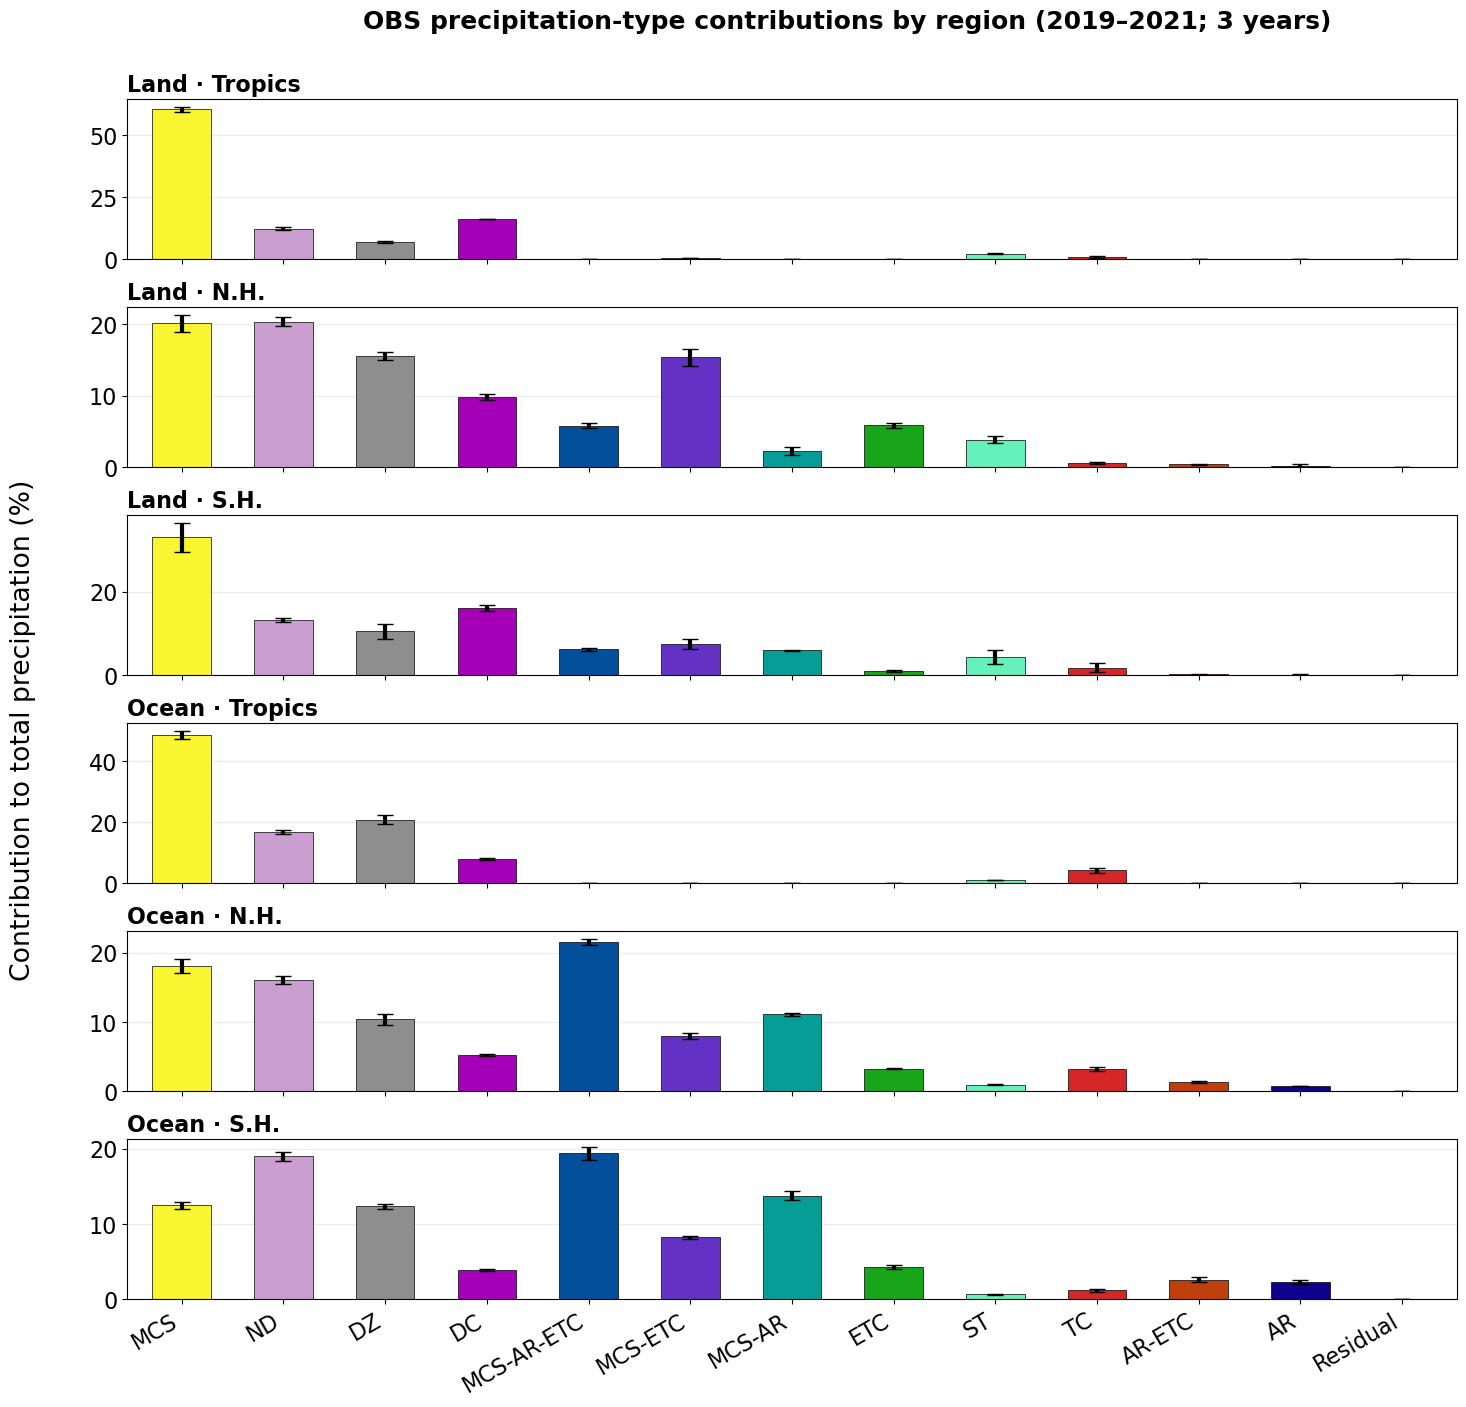

In [69]:
def plot_obs_interannual_bars(
    yearly, summary, type_names, type_colors, region_order, region_labels, figname,
):
    """Plot six regional mean and annual standard-deviation bar charts."""
    # One common type order keeps each x position meaningful across all rows.
    overall_mean = summary['mean'].sel(region=region_order).mean('region')
    order = np.argsort(-overall_mean.sel(type=type_names).values, kind='stable')
    sorted_types = [type_names[i] for i in order]
    color_by_type = dict(zip(type_names, type_colors))
    x = np.arange(len(sorted_types)) * 1.3

    fig = plt.figure(figsize=(18, 15))
    gs = fig.add_gridspec(
        6, 2, width_ratios=[1, 0.025], hspace=0.3, wspace=0.06,
        left=0.10, right=0.88, top=0.92, bottom=0.12,
    )
    axes = []
    upper = float((summary['mean'] + summary['std']).max())
    # y_limit = max(10, np.ceil(upper / 10) * 10)
    y_limit = None

    for i, region in enumerate(region_order):
        # ax = fig.add_subplot(gs[i, 0], sharex=axes[0] if axes else None,
        #                      sharey=axes[0] if axes else None)
        ax = fig.add_subplot(gs[i, 0], sharex=axes[0] if axes else None)
        axes.append(ax)
        means = summary['mean'].sel(region=region, type=sorted_types).values
        stds = summary['std'].sel(region=region, type=sorted_types).values
        ax.bar(
            x, means, width=0.75, color=[color_by_type[t] for t in sorted_types],
            edgecolor='black', linewidth=0.5, zorder=2,
        )
        # Percentages cannot fall below zero; cap only the lower whisker there.
        ax.errorbar(
            x, means, yerr=[np.minimum(stds, means), stds],
            fmt='none', ecolor='black', elinewidth=3, capsize=6, zorder=3,
        )
        ax.set_title(region_labels[region], loc='left', fontsize=16, fontweight='bold')
        # ax.set_ylim(0, y_limit)
        ax.set_xlim(x[0] - 0.7, x[-1] + 0.7)
        ax.grid(axis='y', alpha=0.25, zorder=0)
        ax.set_xticks(x)
        ax.tick_params(axis='x', labelbottom=i == len(region_order) - 1)

    axes[-1].set_xticklabels(sorted_types, rotation=30, ha='right')
    fig.supylabel('Contribution to total precipitation (%)', x=0.035)
    years = yearly.year.values
    year_label = str(years[0]) if len(years) == 1 else f'{years[0]}–{years[-1]}'
    fig.suptitle(
        f'OBS precipitation-type contributions by region ({year_label}; {len(years)} years)',
        fontsize=18, fontweight='bold',
    )

    # # Divider between the three Land rows and three Ocean rows.
    # fig.canvas.draw()
    # y_divider = (axes[2].get_position().y0 + axes[3].get_position().y1) / 2
    # fig.add_artist(mpl.lines.Line2D(
    #     [axes[0].get_position().x0, axes[0].get_position().x1],
    #     [y_divider, y_divider], transform=fig.transFigure,
    #     color='black', linewidth=1.5,
    # ))

    # cmap = ListedColormap(type_colors)
    # norm = BoundaryNorm(np.arange(0.5, len(type_names) + 1.5), cmap.N)
    # cax = fig.add_subplot(gs[:, 1])
    # colorbar = fig.colorbar(
    #     mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax,
    #     ticks=np.arange(1, len(type_names) + 1), orientation='vertical',
    # )
    # colorbar.ax.set_yticklabels(type_names)
    # colorbar.ax.invert_yaxis()  # Match the pie legend's MCS-to-Residual order
    # colorbar.set_label('Precipitation type')
    fig.savefig(figname, dpi=200, bbox_inches='tight', facecolor='white')
    print(f'Figure saved: {figname}')
    return fig

obs_interannual_figname = f'{figdir}BarChart_StormType_Fraction_Total_OBS_6x1_interannual.png'
fig = plot_obs_interannual_bars(
    obs_region_year_fraction, obs_region_summary, obs_type_names, obs_type_colors,
    obs_region_order, obs_region_labels, obs_interannual_figname,
)
plt.show()


### Other useful views

- **Annual-value dot plot:** show every year's value for each type and region. This makes the
  three observed values behind each standard-deviation whisker visible.
- **Year-by-type anomaly heatmap:** show each year's departure from its regional multi-year
  mean. Small multiples for the six regions would reveal coordinated changes among types.
